In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("../data/cleaned/16P.csv" , encoding="latin1")

In [17]:
df.drop("Response Id" , axis=1 , inplace=True)

In [18]:
personalities = pd.DataFrame({
    "Is_Extrovert": df["Personality"].map(lambda x: 1 if x[0] == 'E' else 0),
    "Is_Sensor": df["Personality"].map(lambda x: 1 if x[1] == 'S' else 0),
    "Is_Thinker": df["Personality"].map(lambda x: 1 if x[2] == 'T' else 0),
    "Is_Judger": df["Personality"].map(lambda x: 1 if x[3] == 'J' else 0)
})

In [19]:
personalities.head()

,Is_Extrovert,Is_Sensor,Is_Thinker,Is_Judger
0,1,0,0,0
1,0,1,0,0
2,0,0,0,1
3,0,1,1,0
4,1,0,0,1


<Axes: >

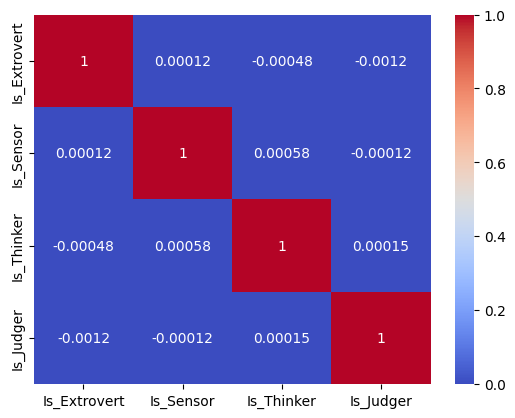

In [20]:
sns.heatmap(personalities.corr(), annot=True, cmap="coolwarm")

In [22]:
df["Personality"] = df["Personality"].astype("category").cat.codes

In [23]:
eda_summary = pd.DataFrame({
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Std": df.std()
})
print(eda_summary.drop("Personality", axis=0))

                                                    Median  Mode       Std
You regularly make new friends.                        0.0     0  0.365701
You spend a lot of your free time exploring var...     0.0     0  0.364652
Seeing other people cry can easily make you fee...     0.0     0  1.527343
You often make a backup plan for a backup plan.        0.0    -1  1.502173
You usually stay calm, even under a lot of pres...     0.0     0  1.502999
At social events, you rarely try to introduce y...     0.0     0  1.521413
You prefer to completely finish one project bef...    -1.0    -1  1.445931
You are very sentimental.                              0.0     0  0.367361
You like to use organizing tools like schedules...     0.0     0  1.537329
Even a small mistake can cause you to doubt you...     0.0     0  0.367347
You feel comfortable just walking up to someone...     0.0     0  1.497501
You are not too interested in discussing variou...     0.0     0  1.532219
You are more inclined to 

In [25]:
target_corr = df.corr(method="spearman")["Personality"].drop("Personality").sort_values(ascending=False)

plt.figure(figsize=(8, 12))
sns.barplot(x=target_corr.values, y=target_corr.index, palette="RdYlGn", hue=df["Personality"])
plt.title("Correlation of Questions with Target")
plt.xlabel("Spearman Correlation Coefficient")
plt.show()

ValueError: array length 60 does not match index length 59999

<Figure size 800x1200 with 0 Axes>

Text(0.5, 1.0, 'Average Answer per Target Category')

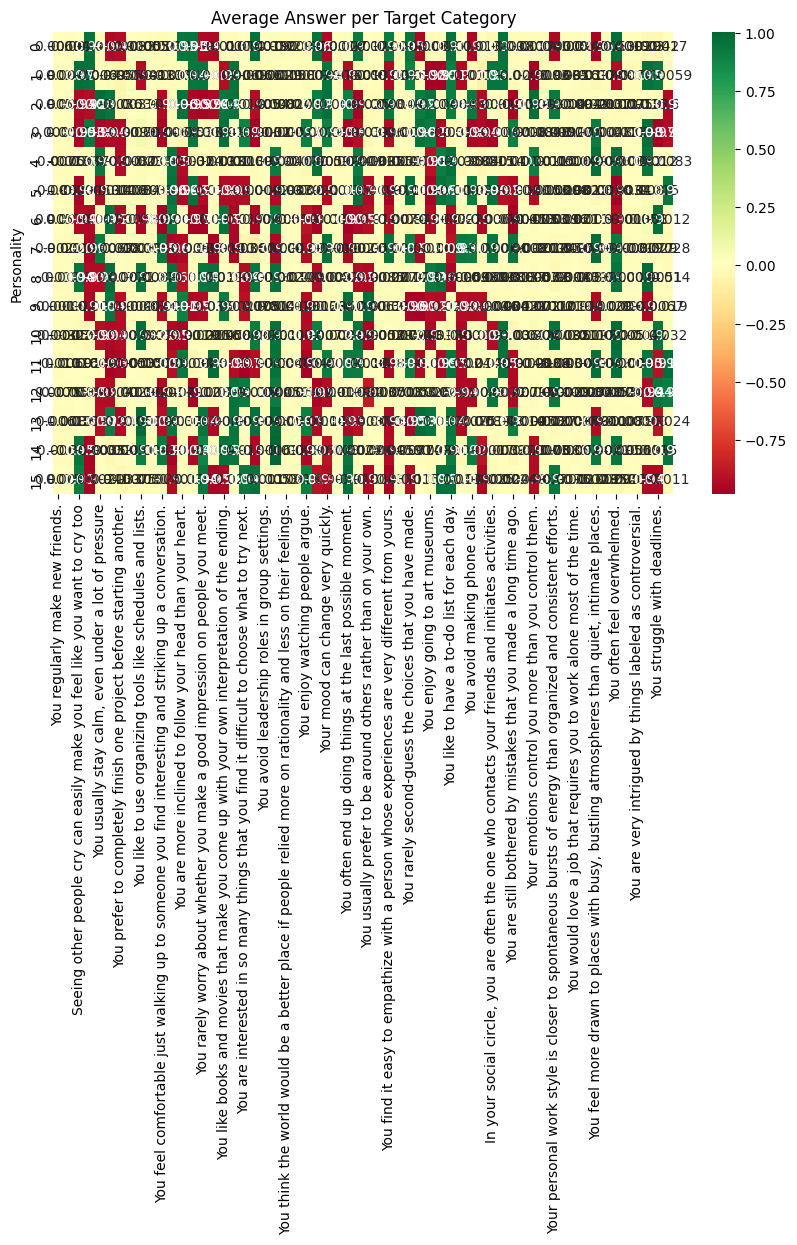

In [ ]:
target_analysis = df.groupby("Personality").mean().drop("Personality")

plt.figure(figsize=(10, 6))
sns.heatmap(target_analysis, annot=True, cmap="RdYlGn")
plt.title("Average Answer per Target Category")

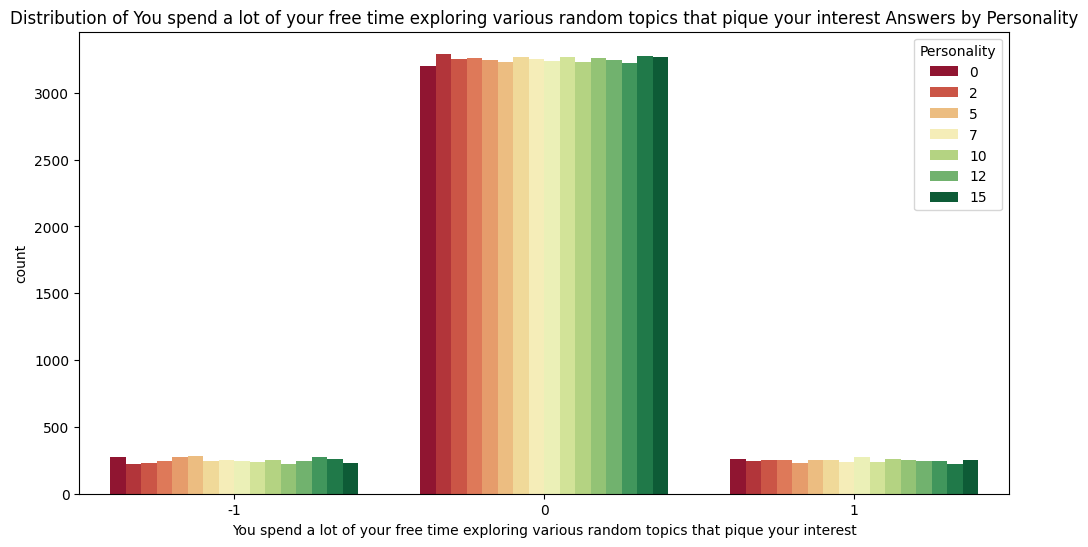

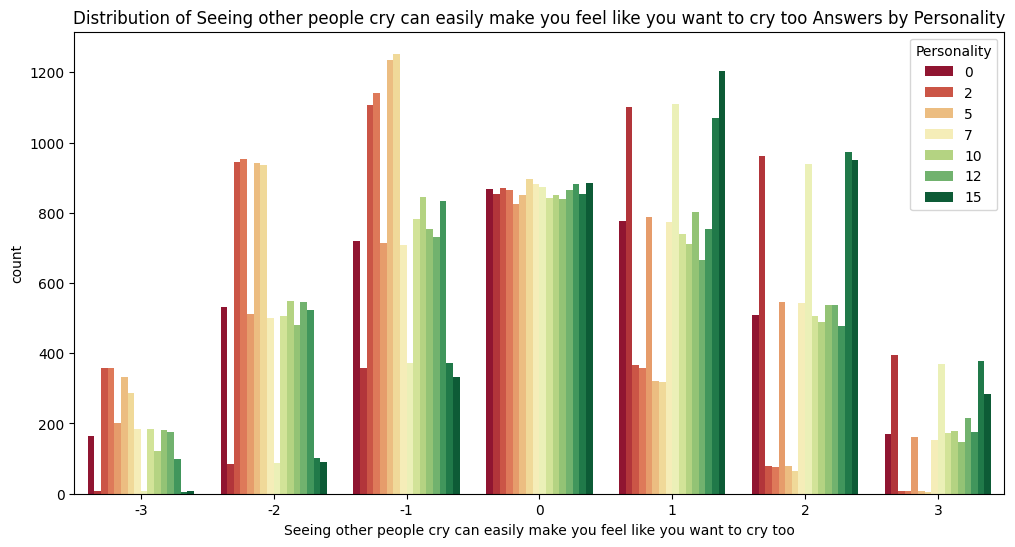

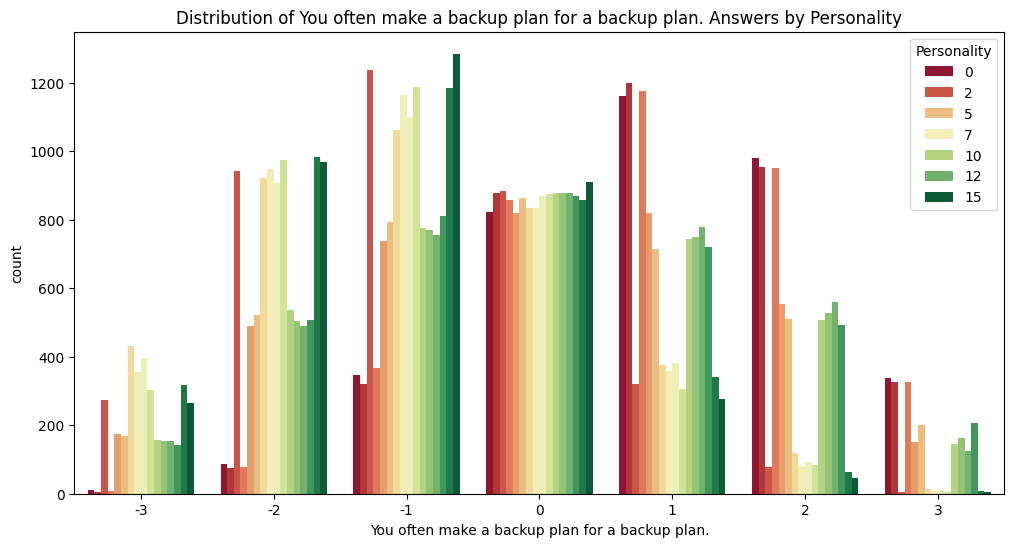

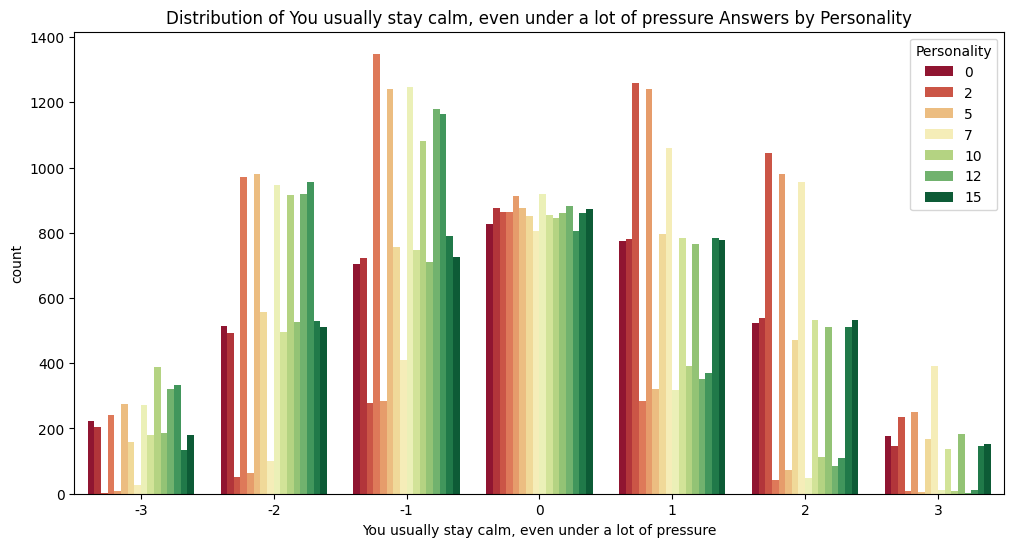

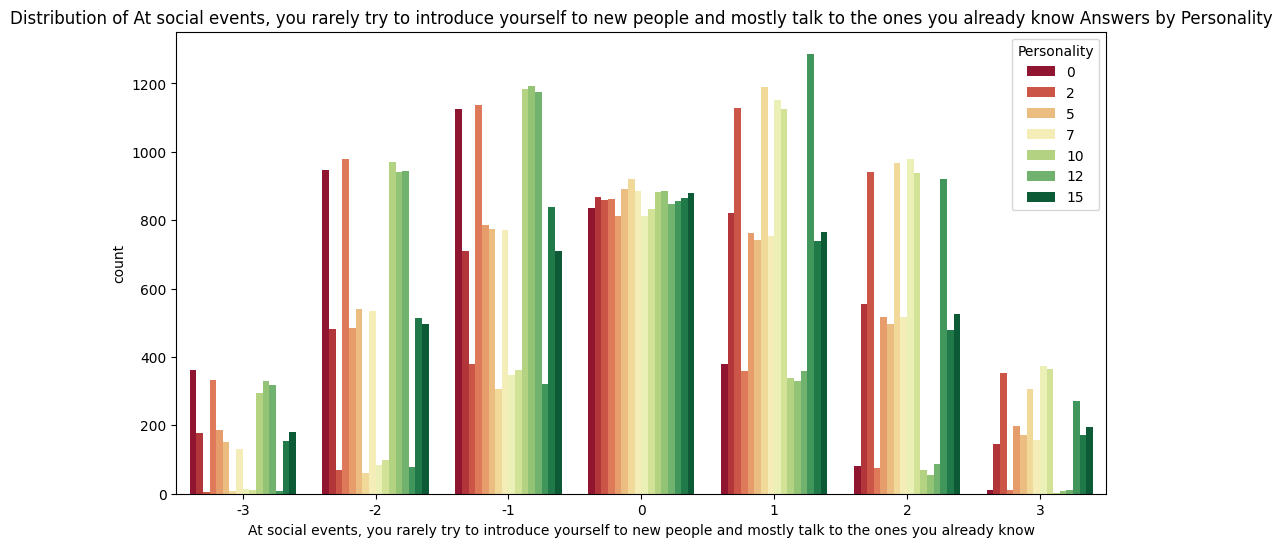

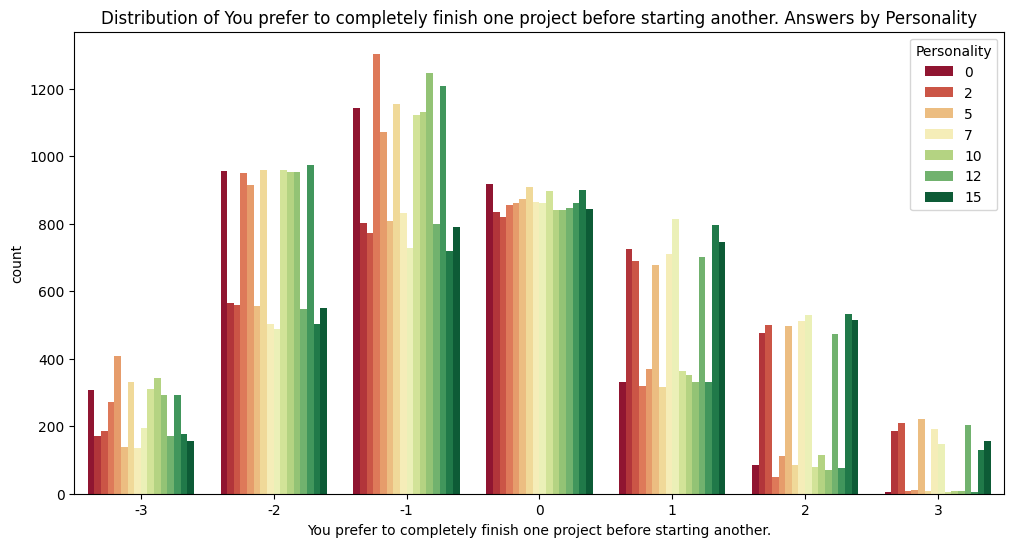

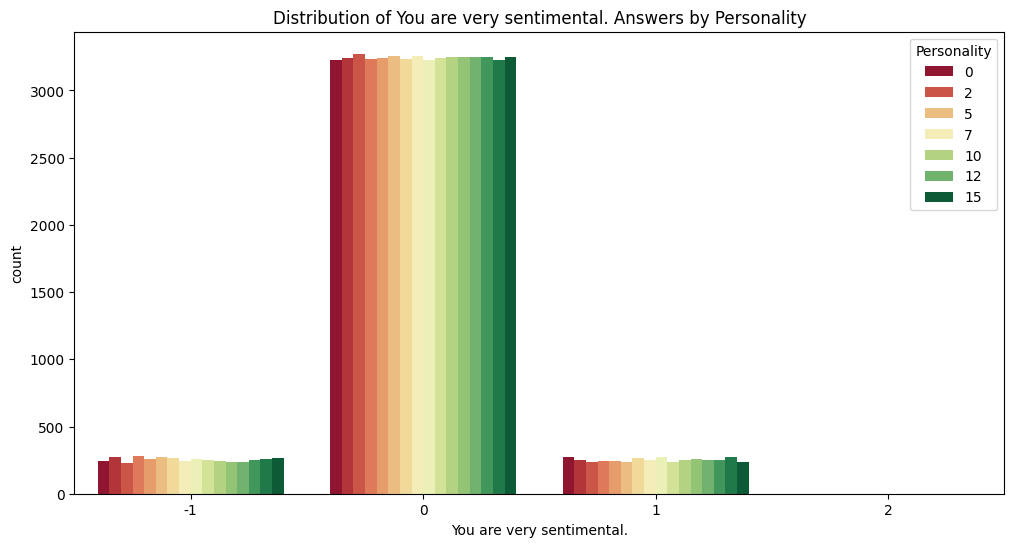

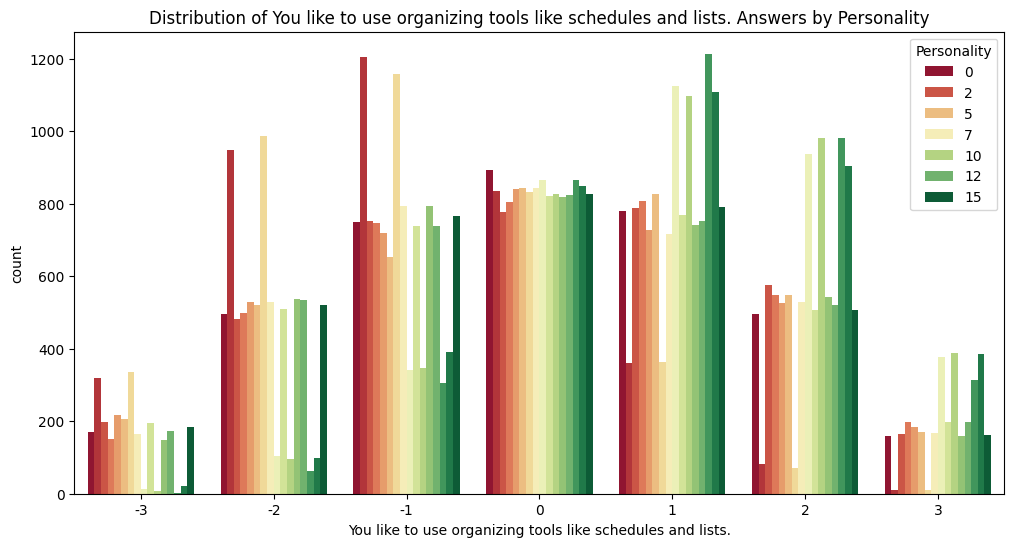

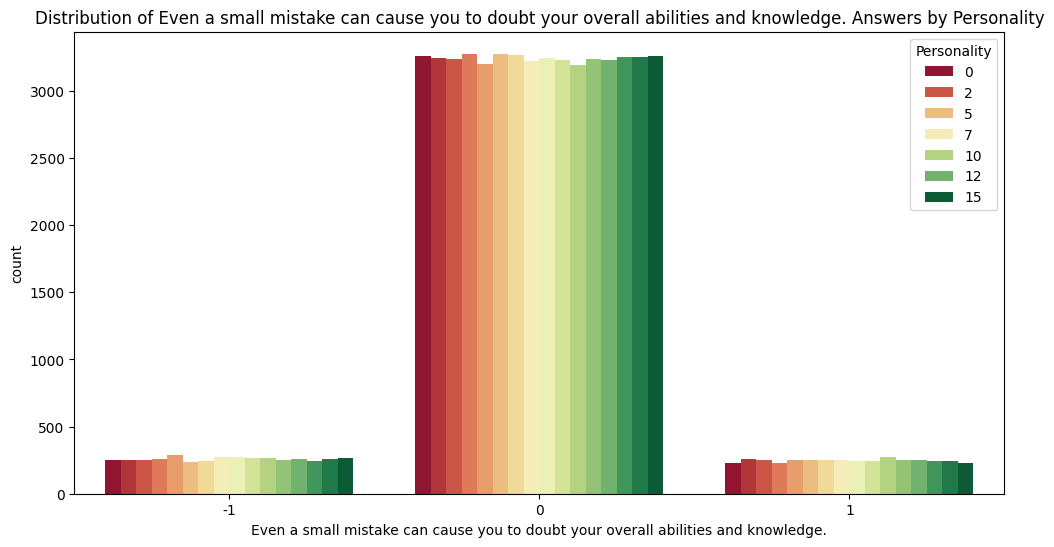

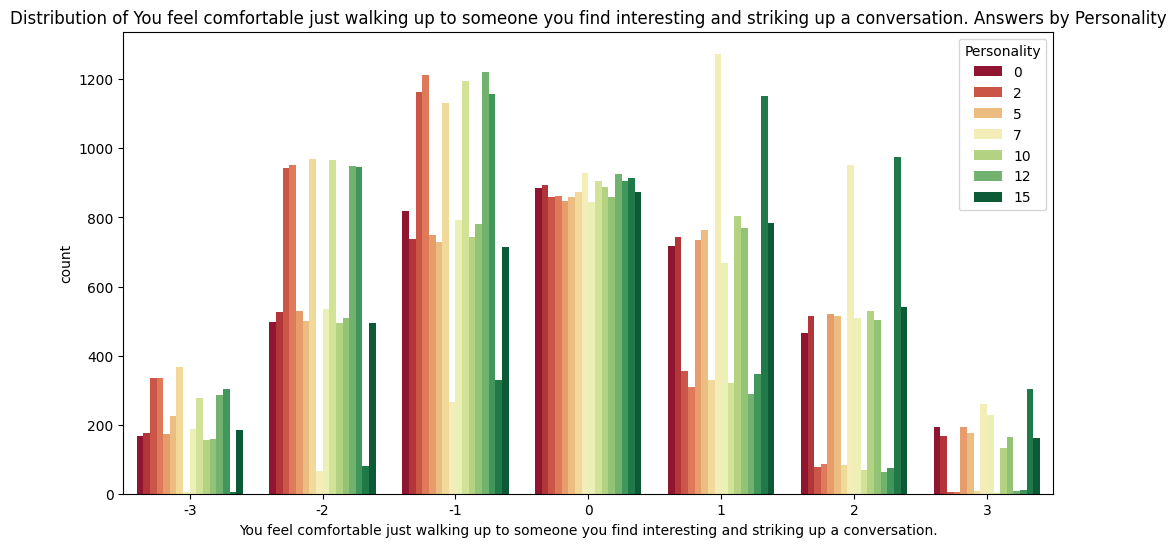

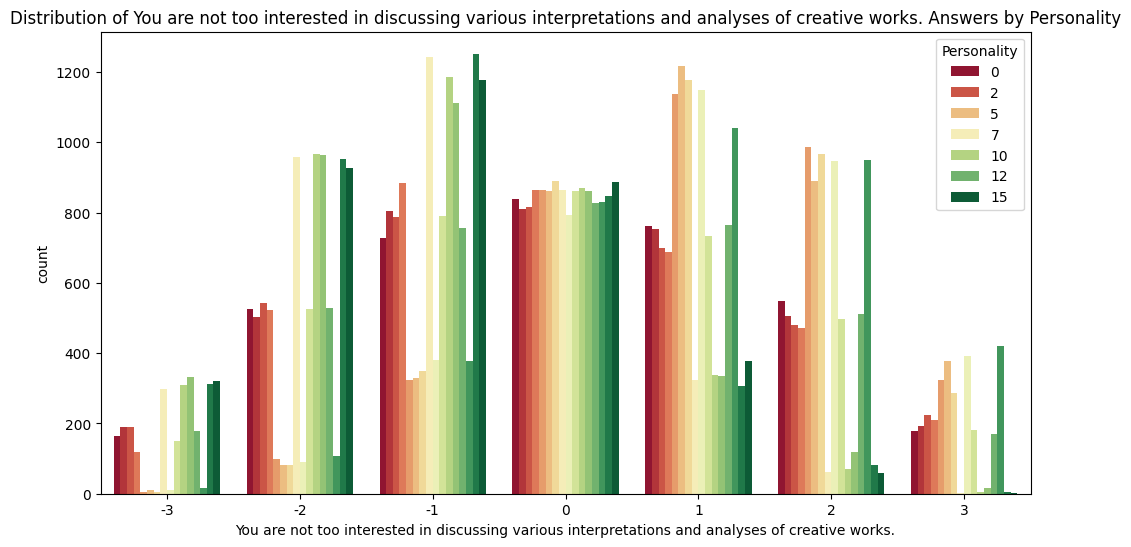

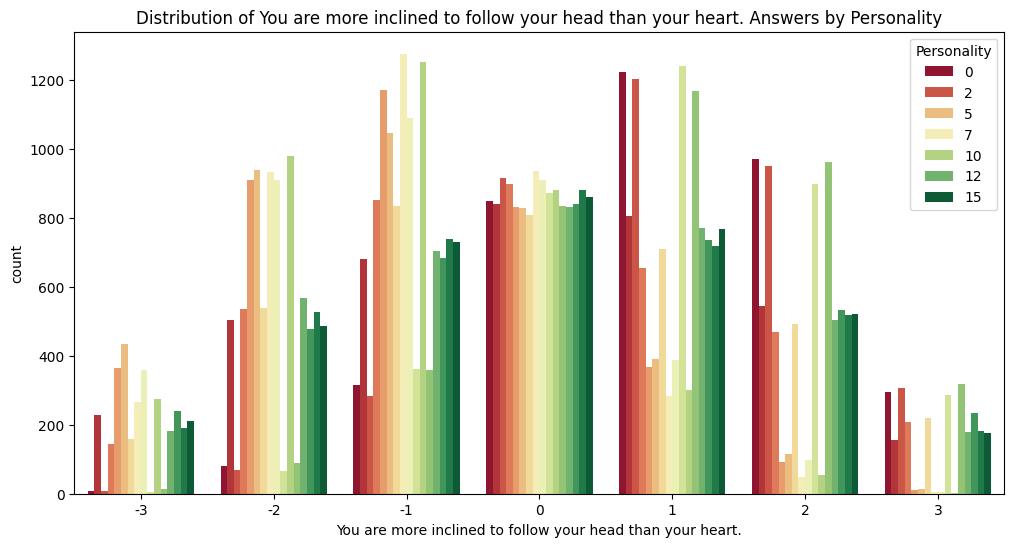

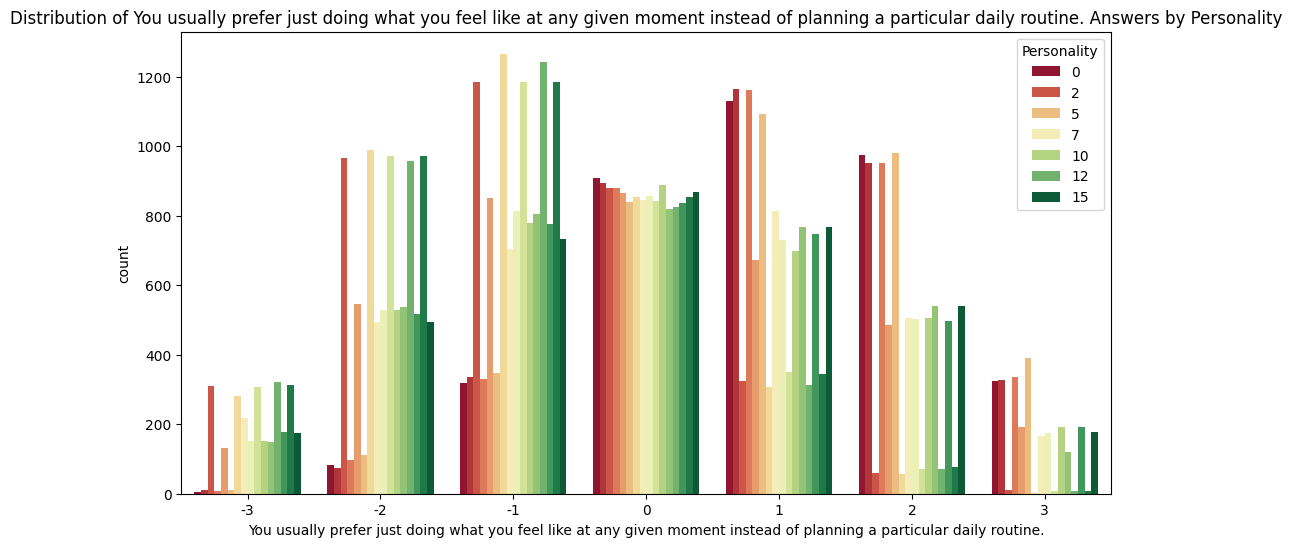

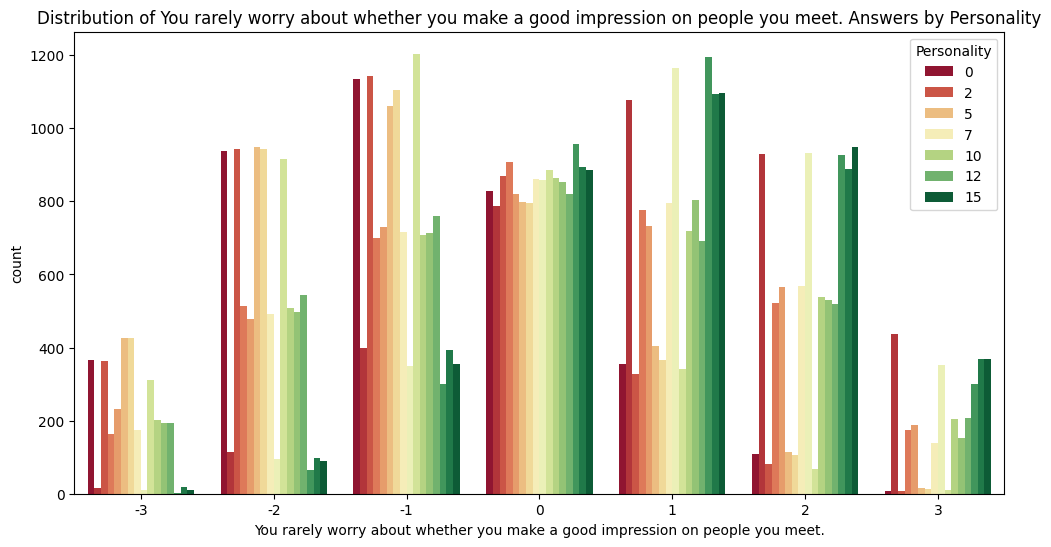

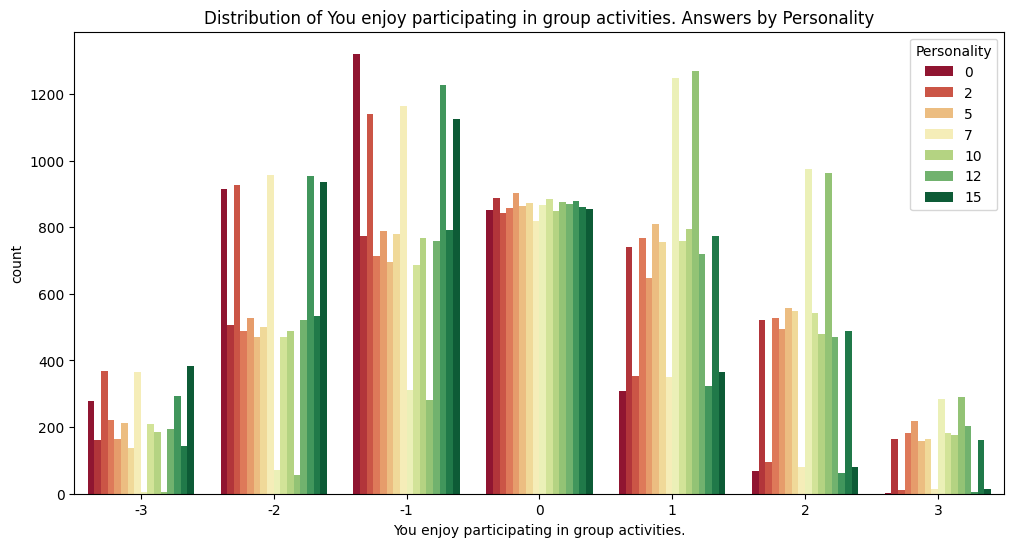

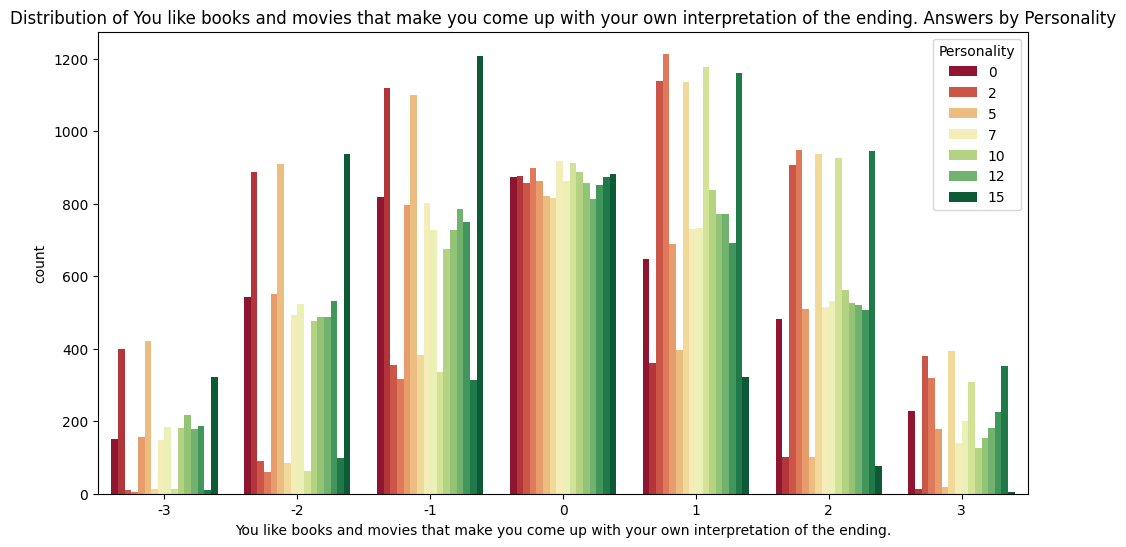

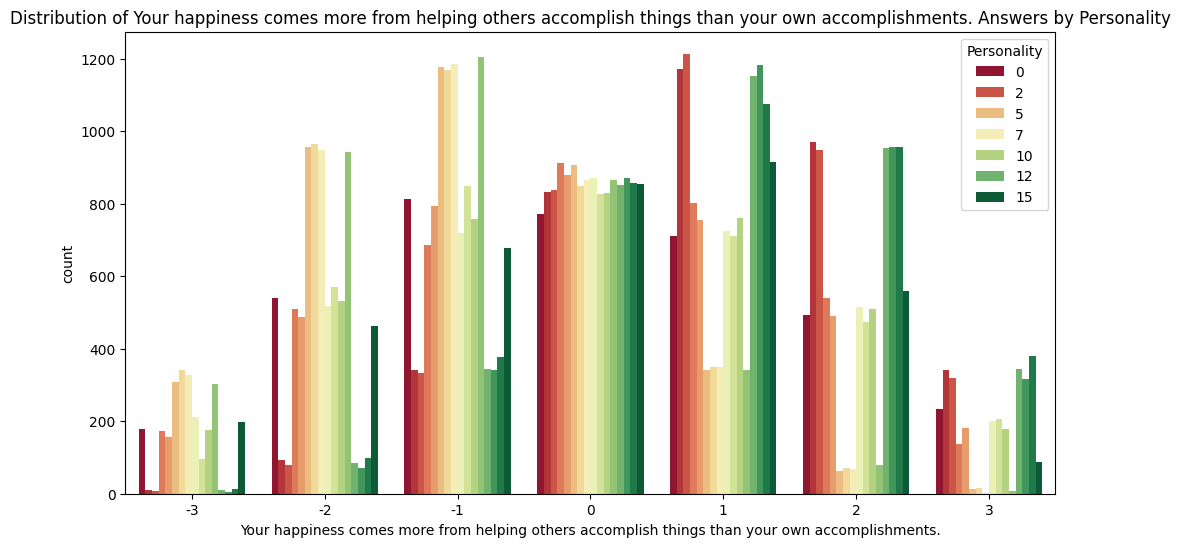

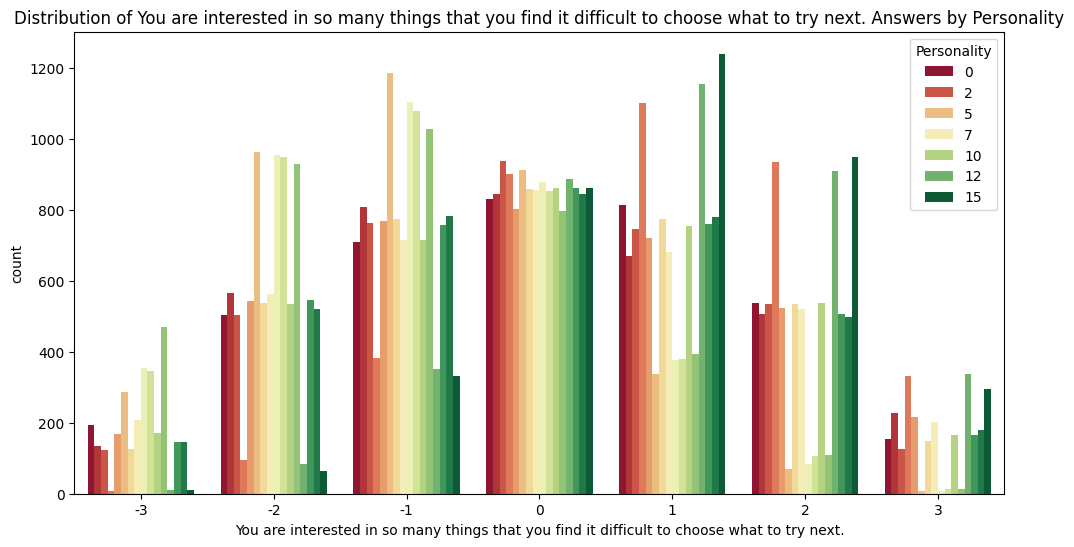

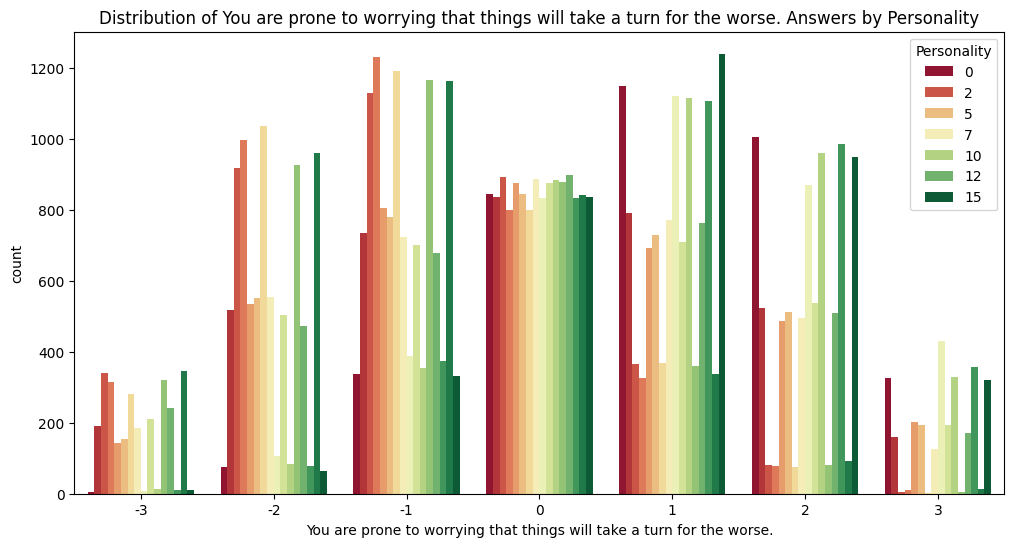

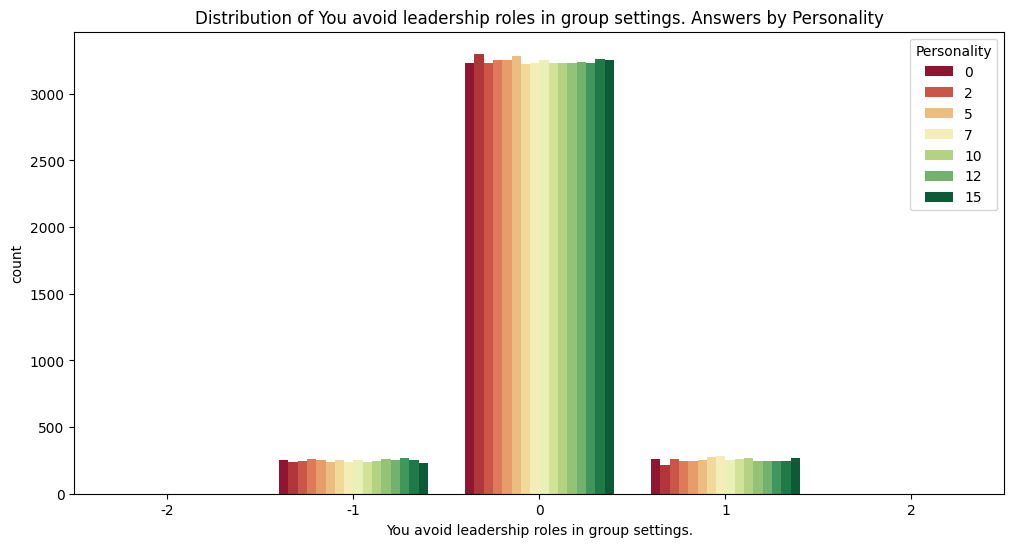

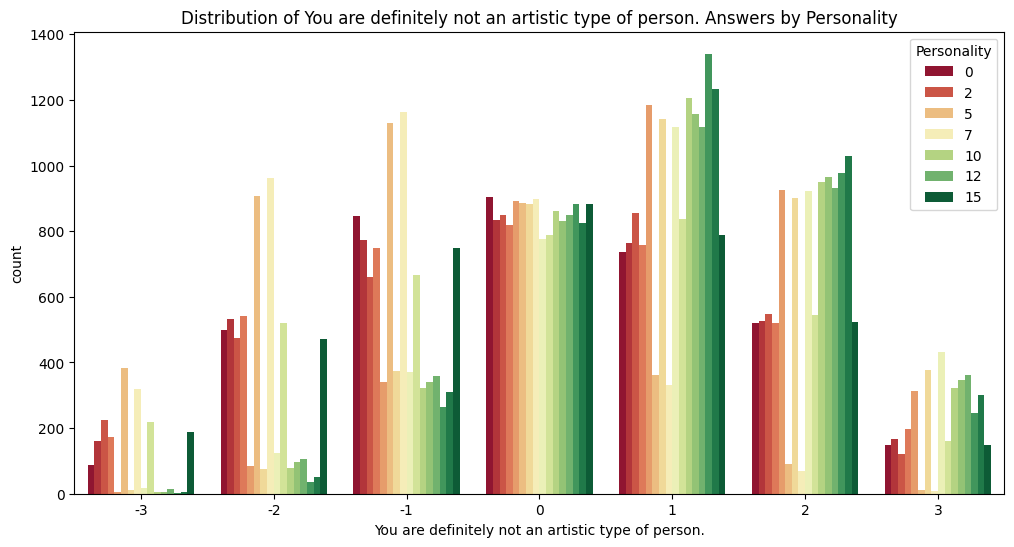

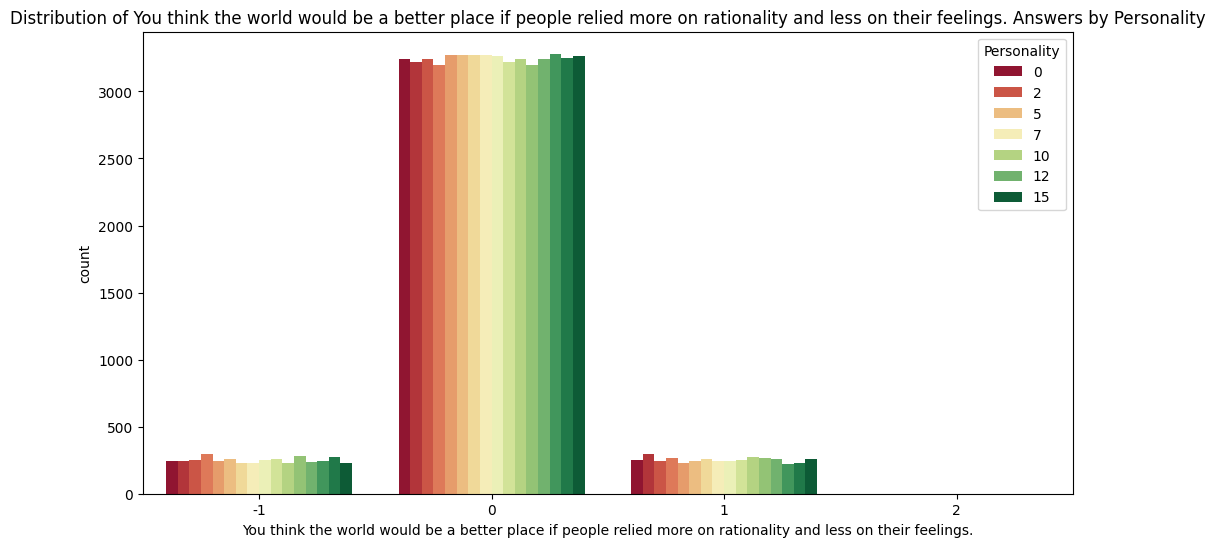

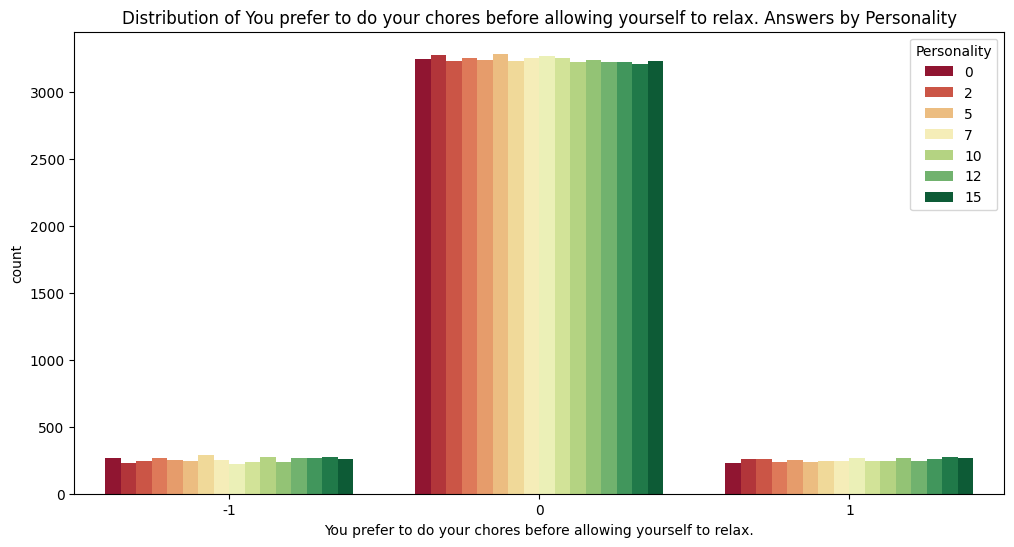

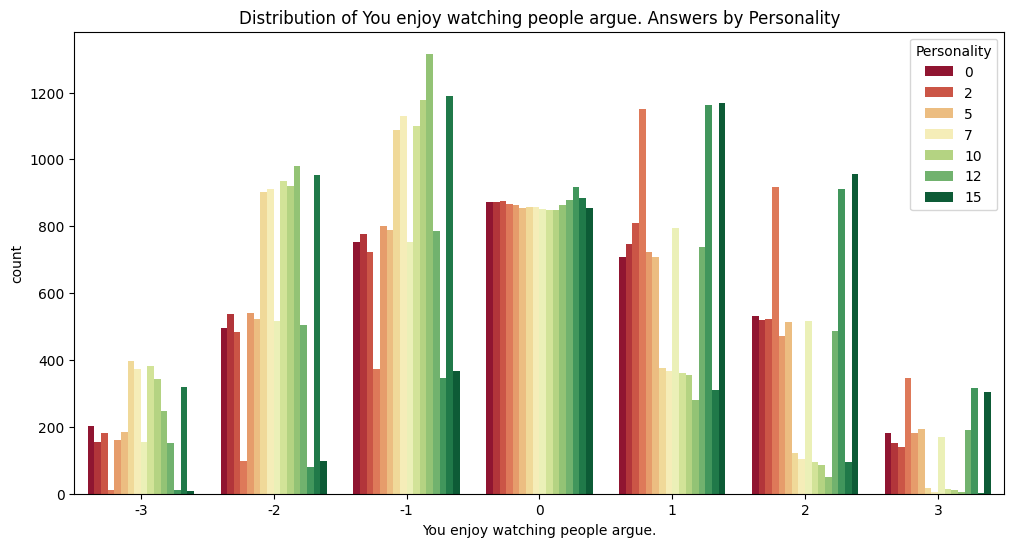

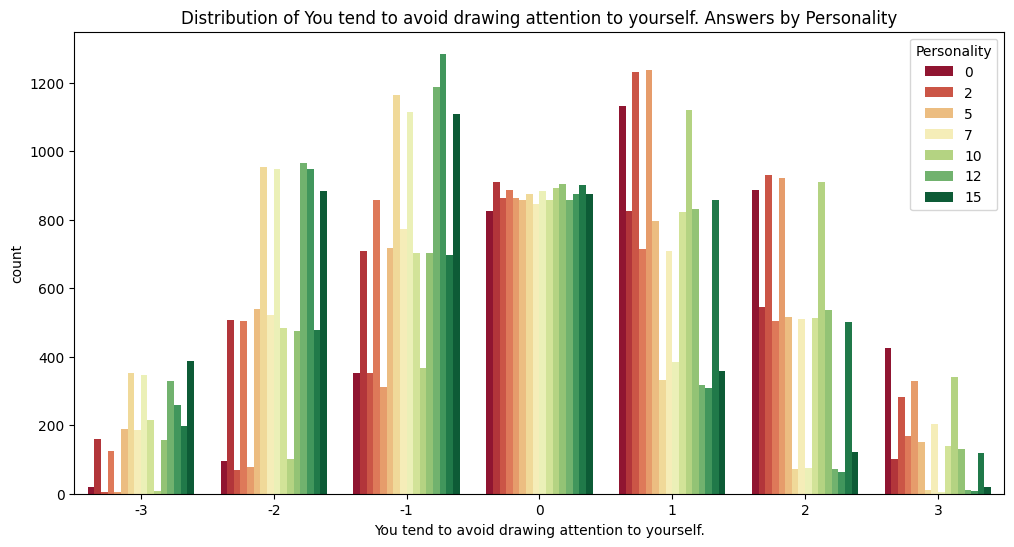

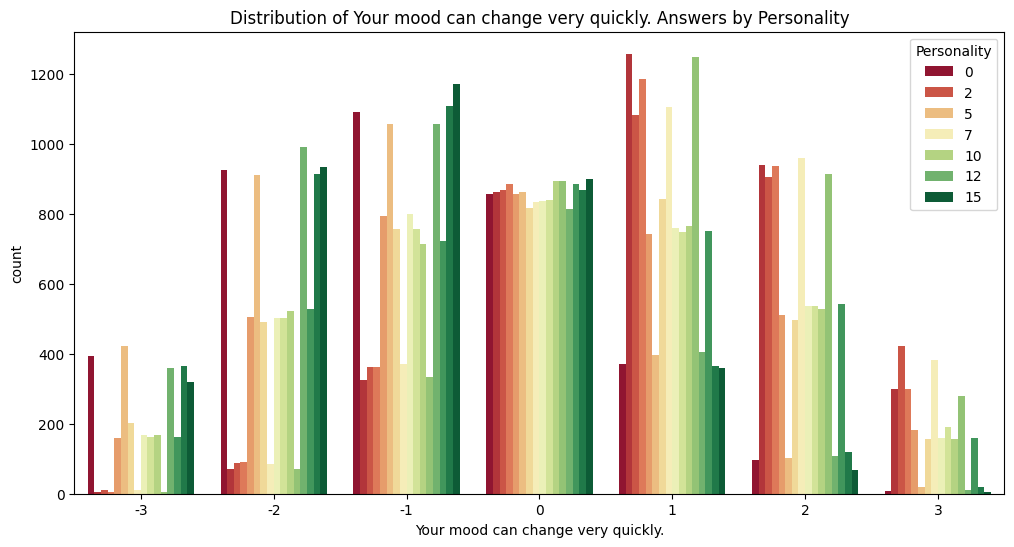

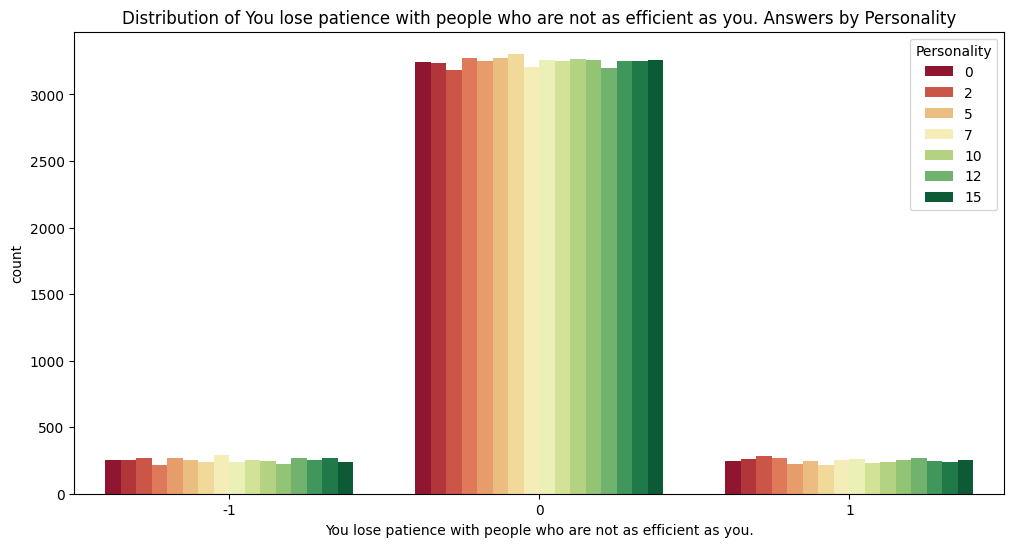

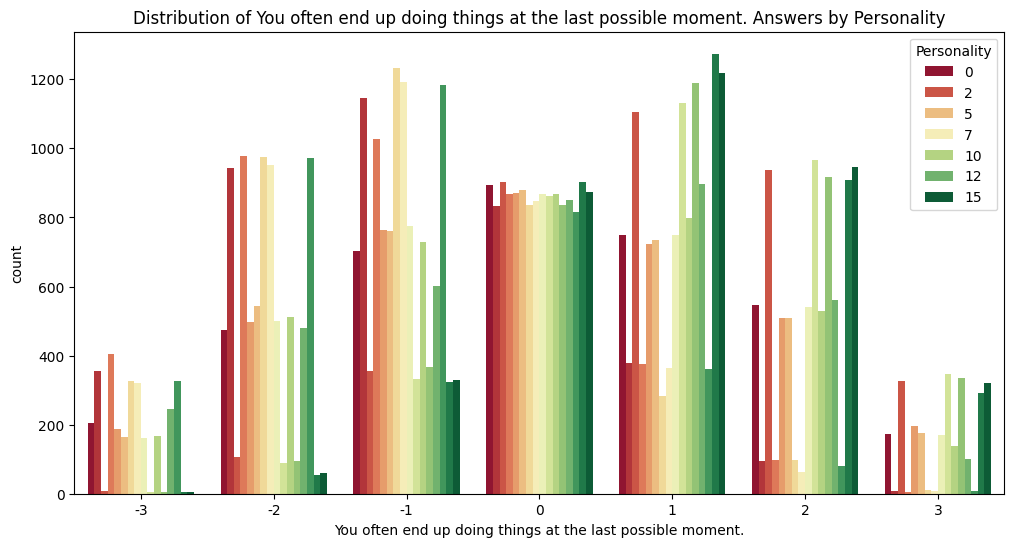

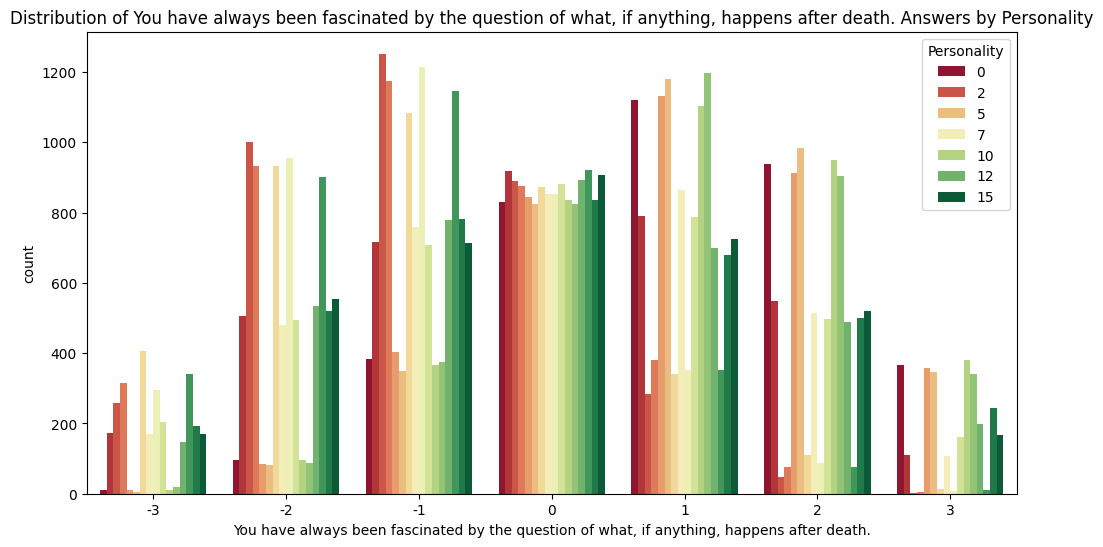

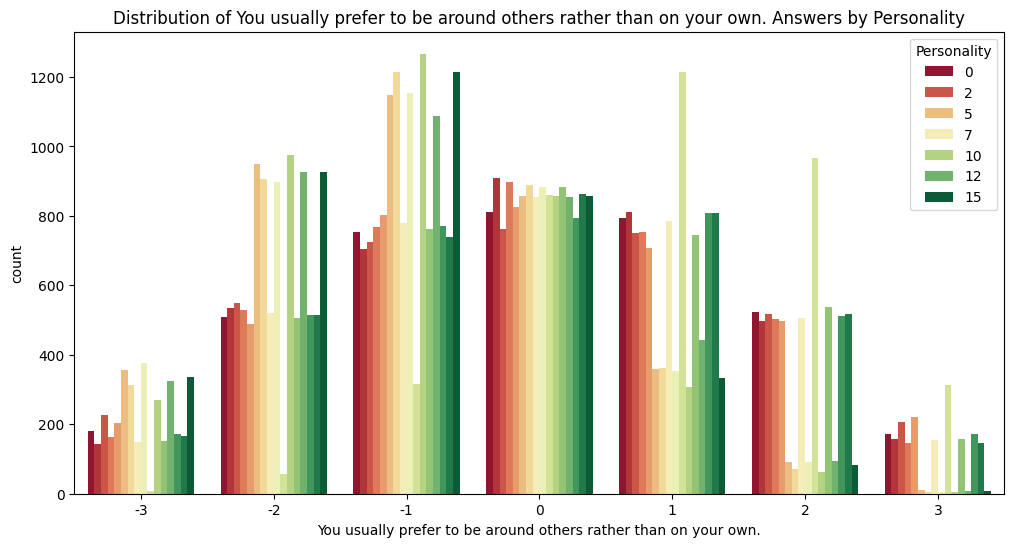

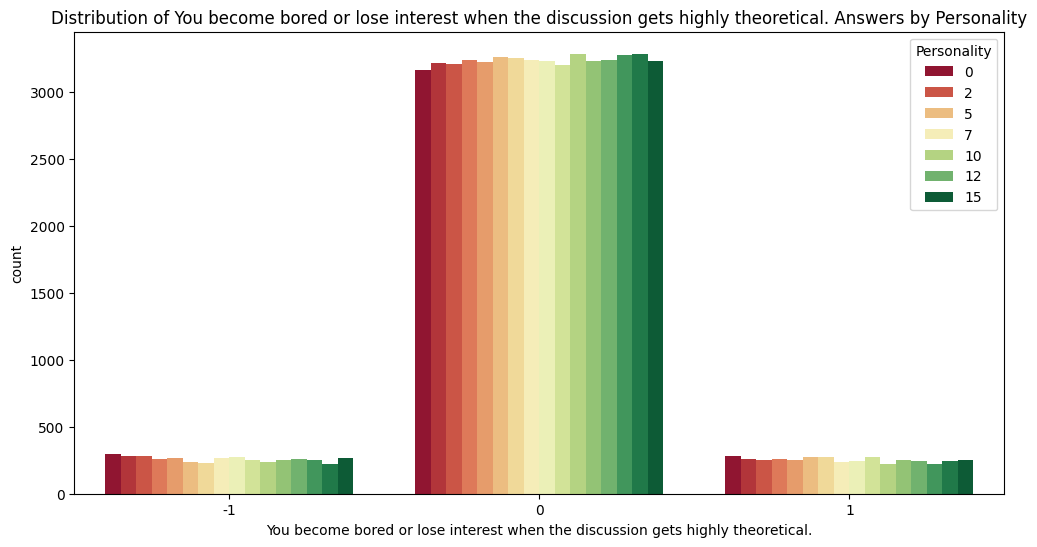

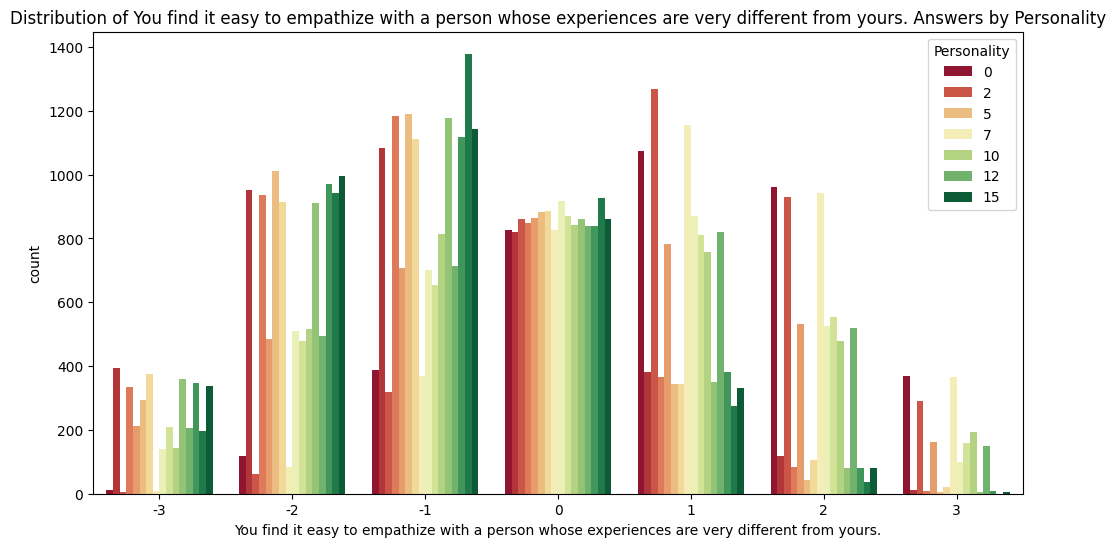

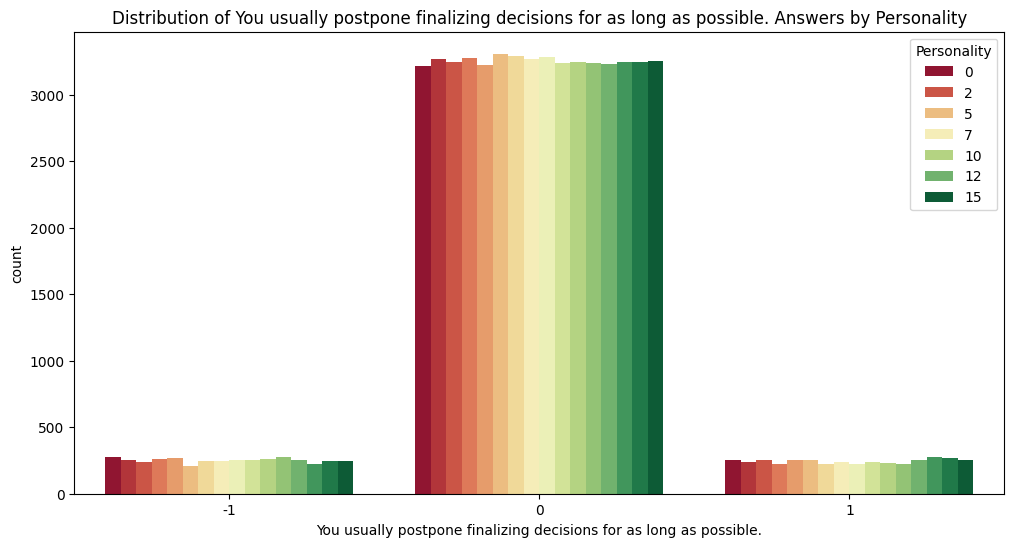

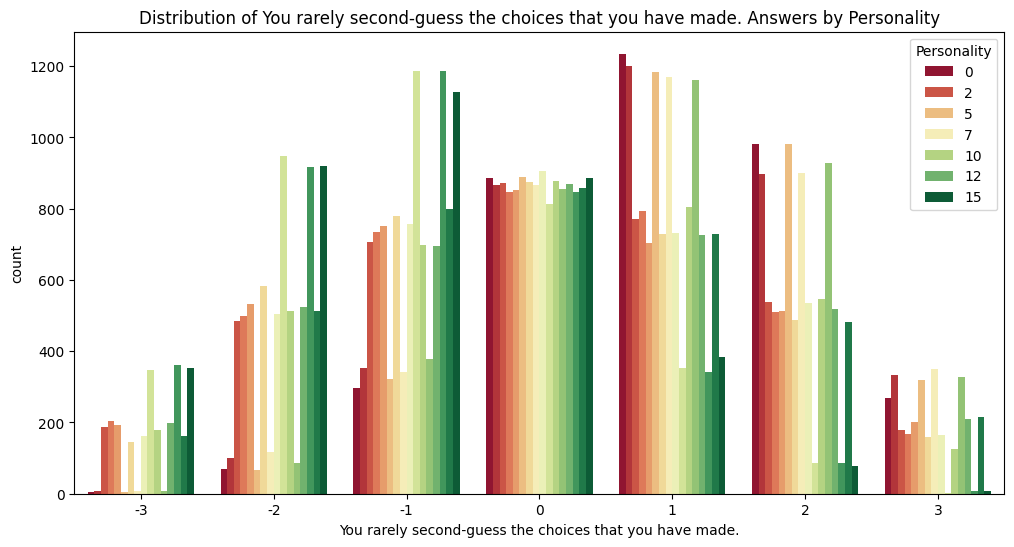

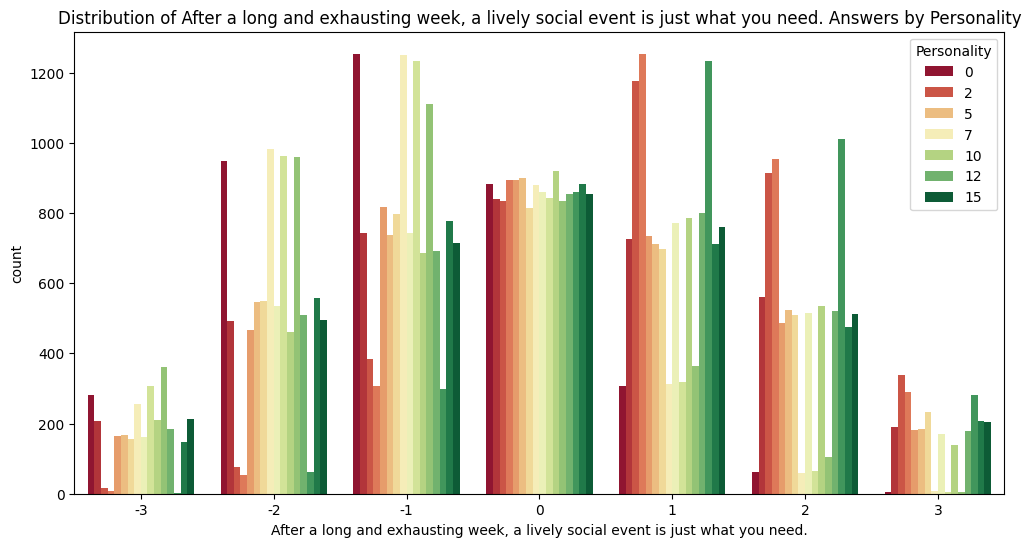

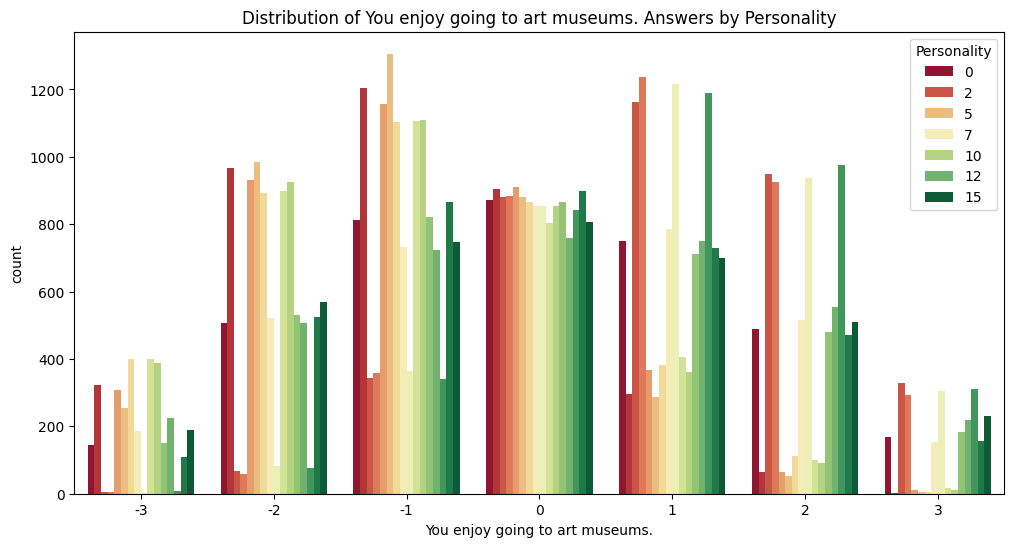

C:\Users\Nour\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 146 (\x92) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


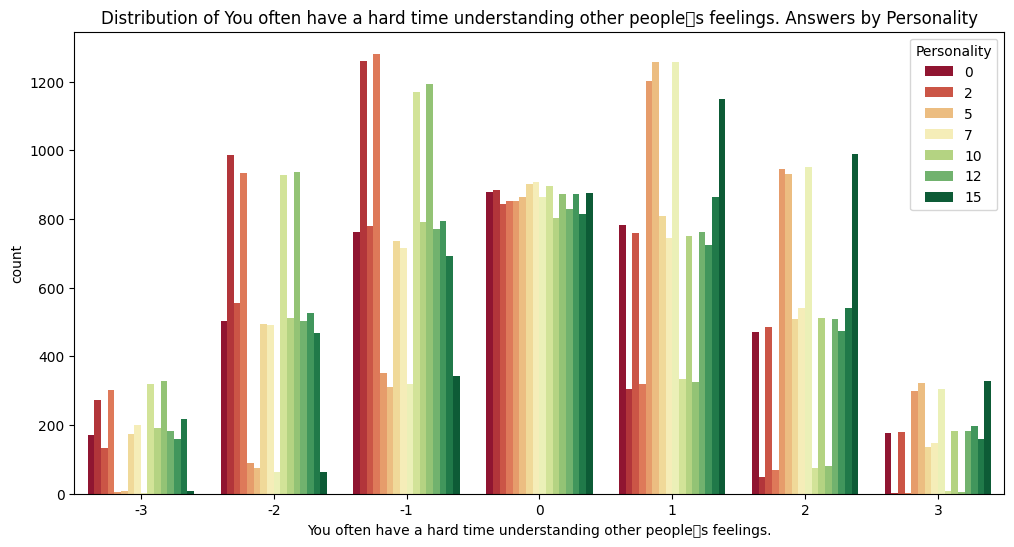

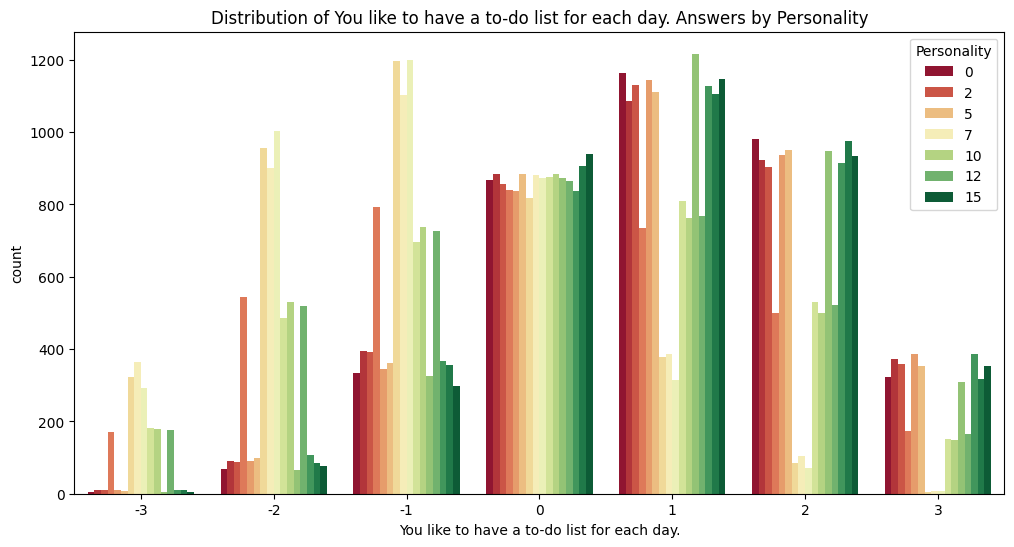

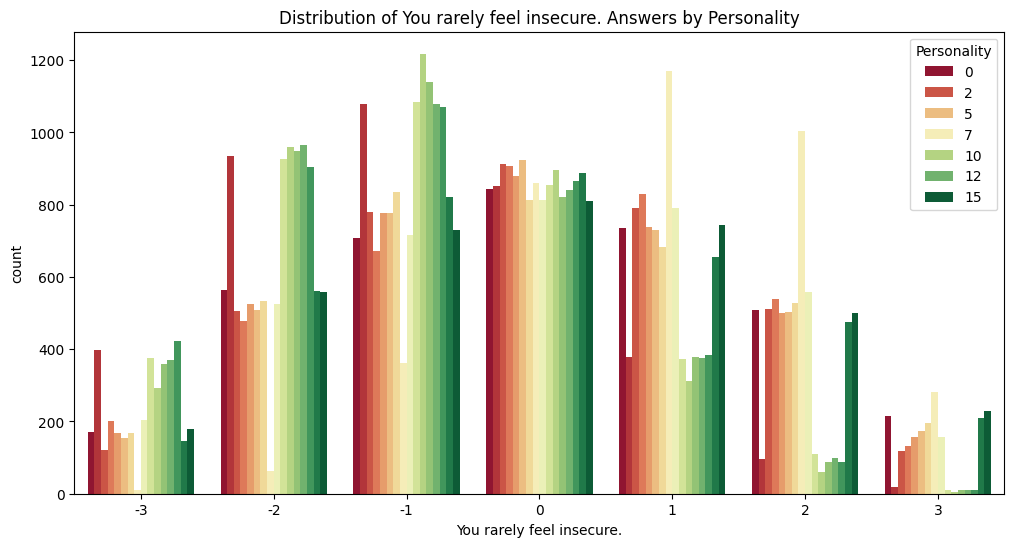

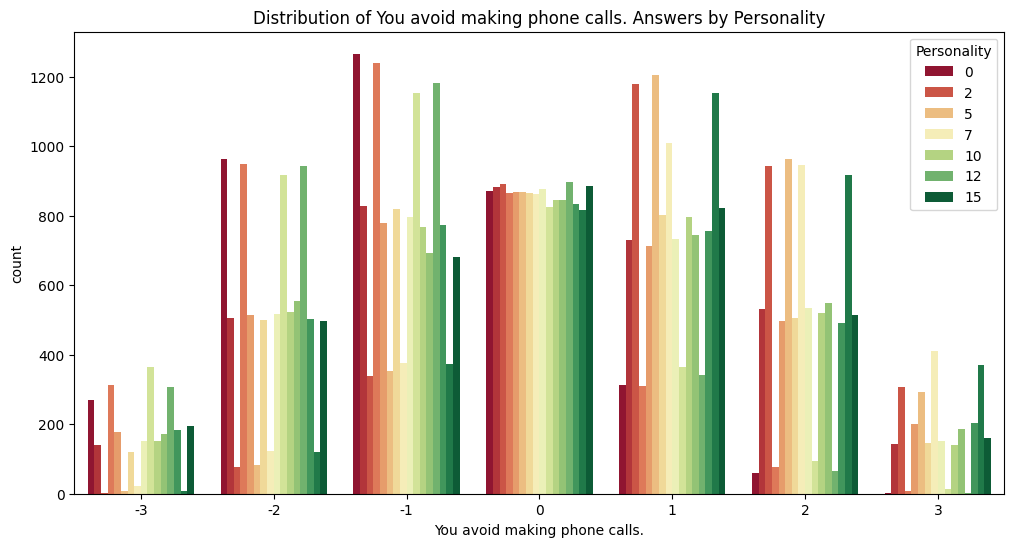

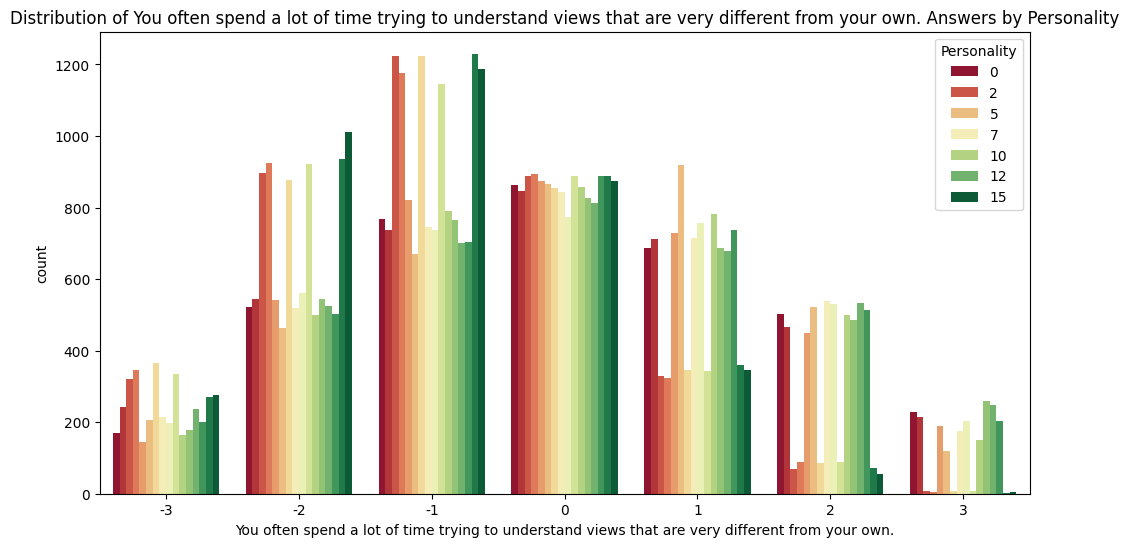

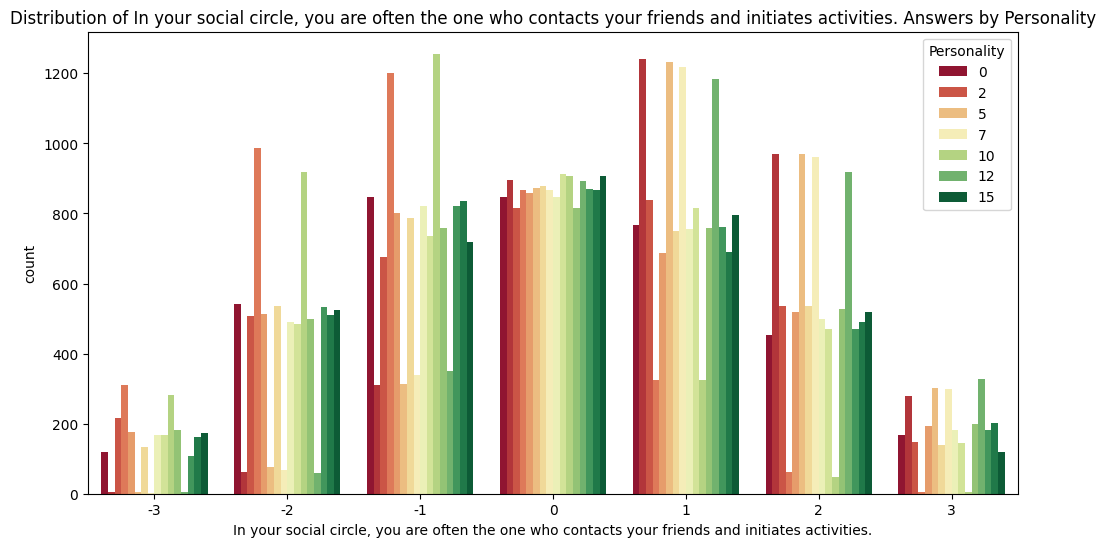

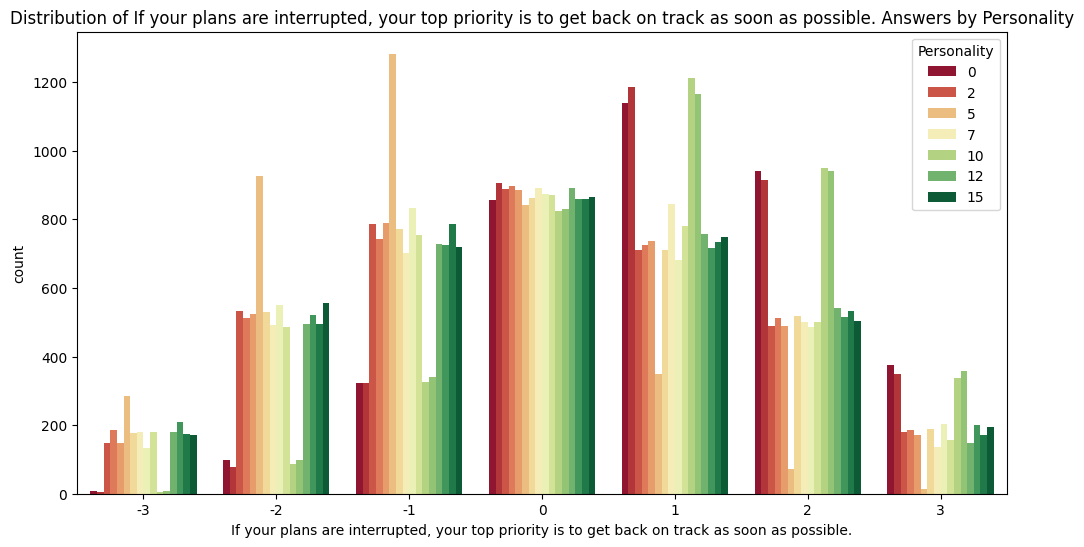

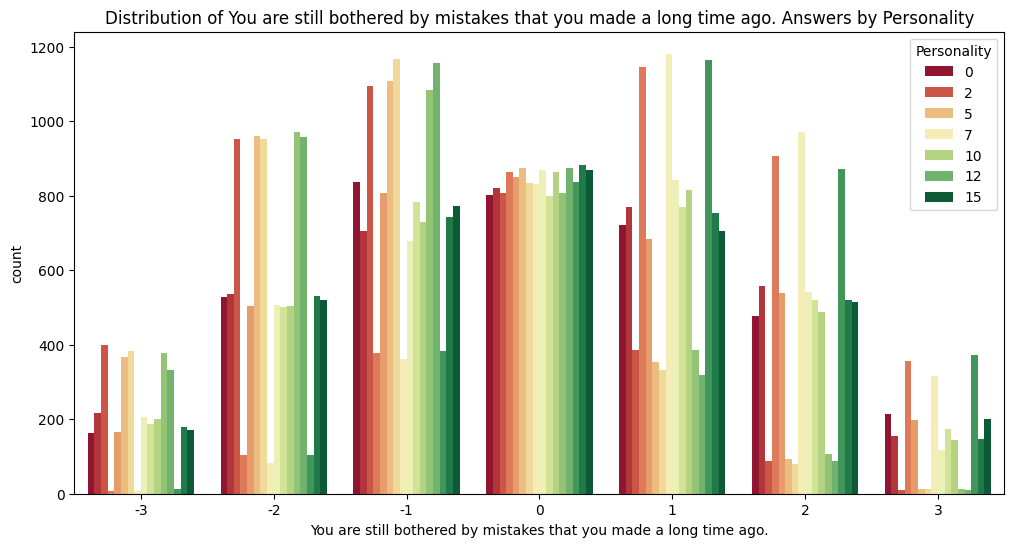

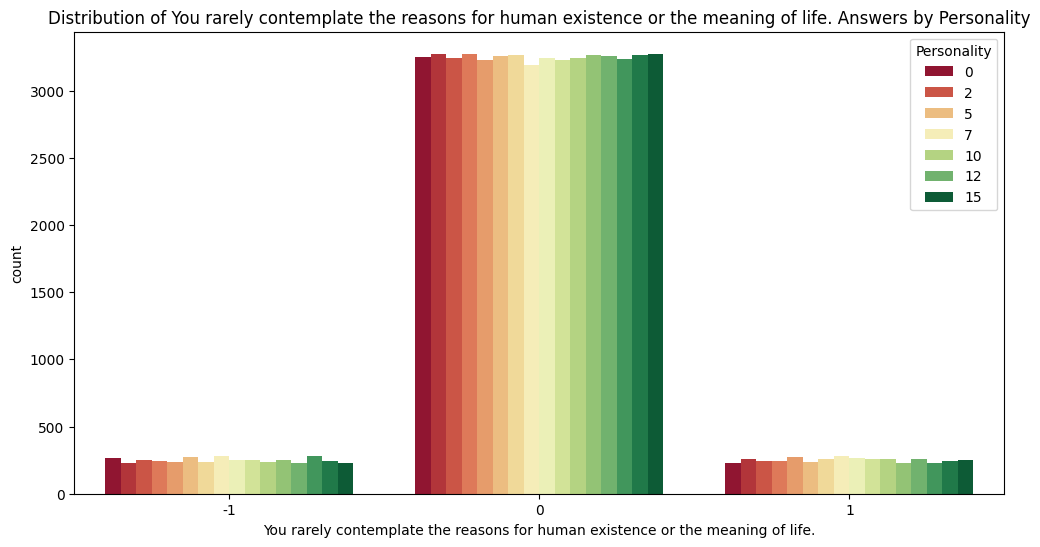

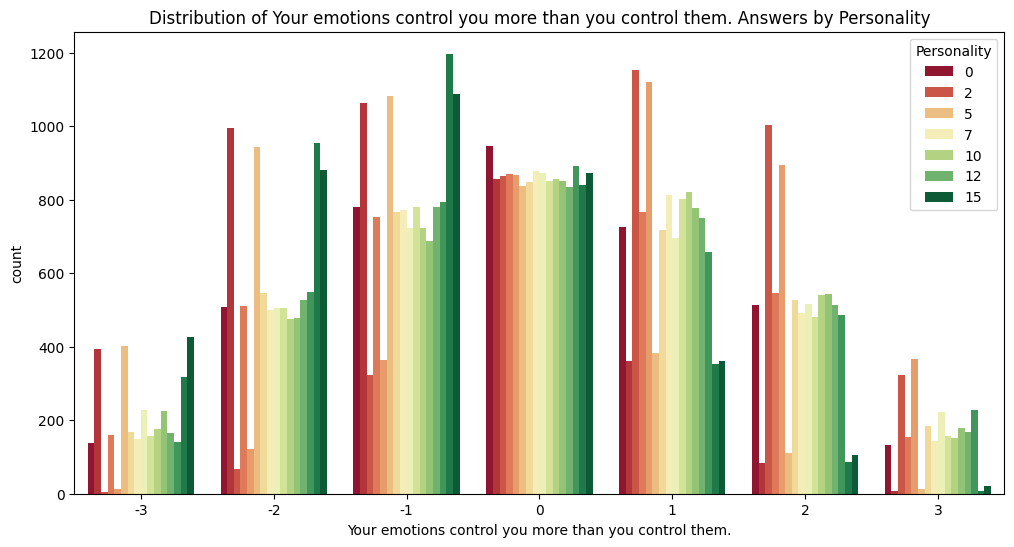

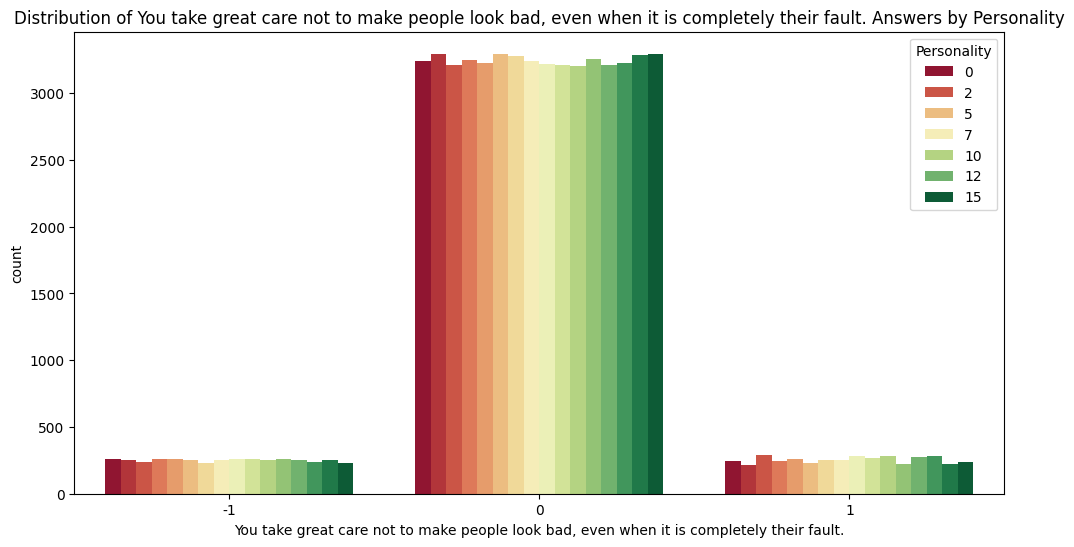

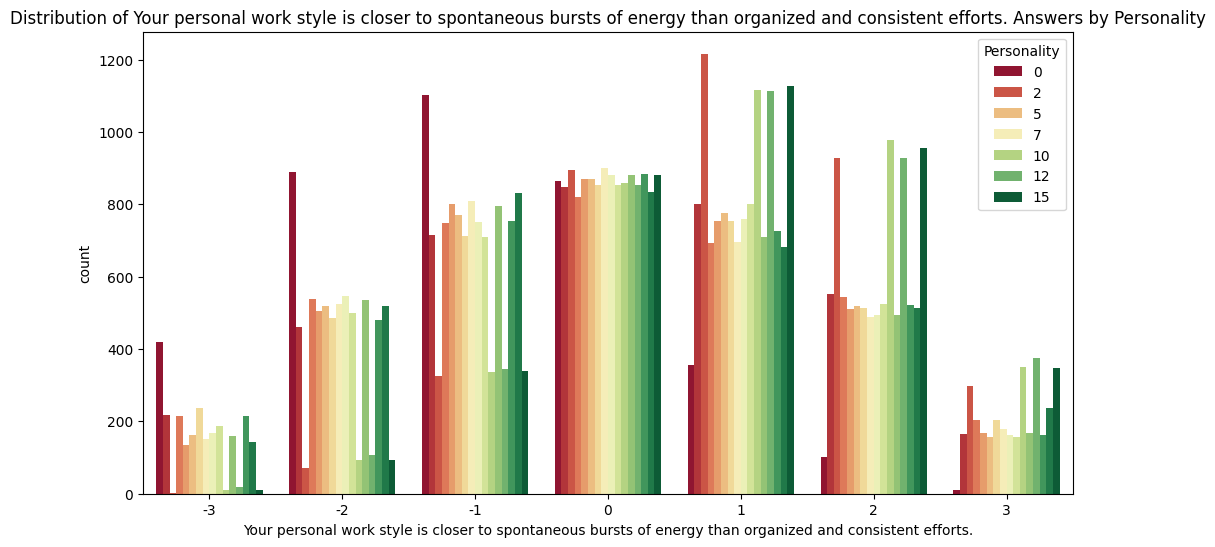

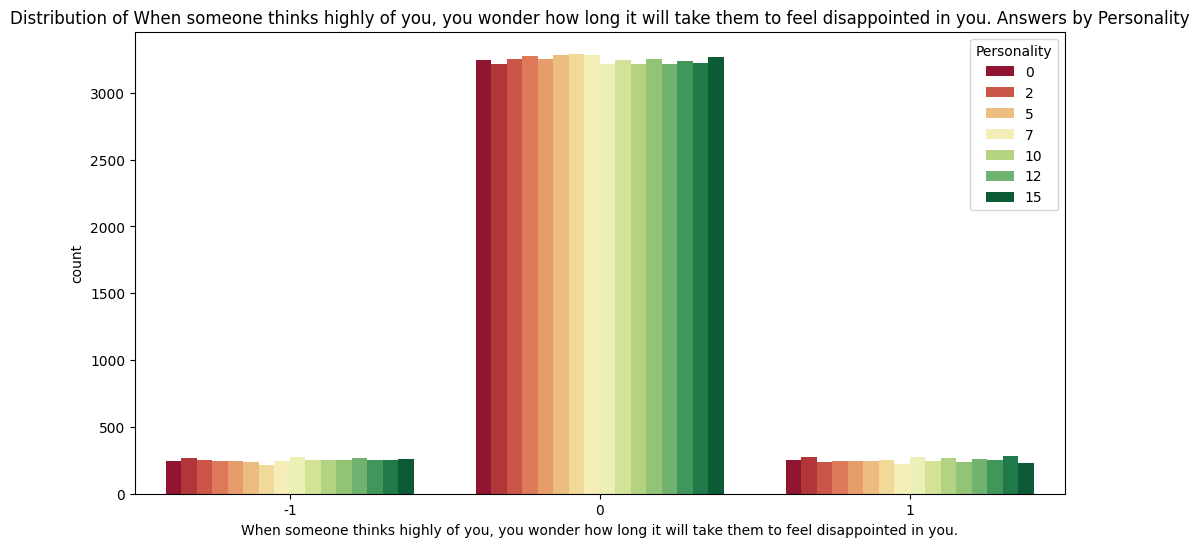

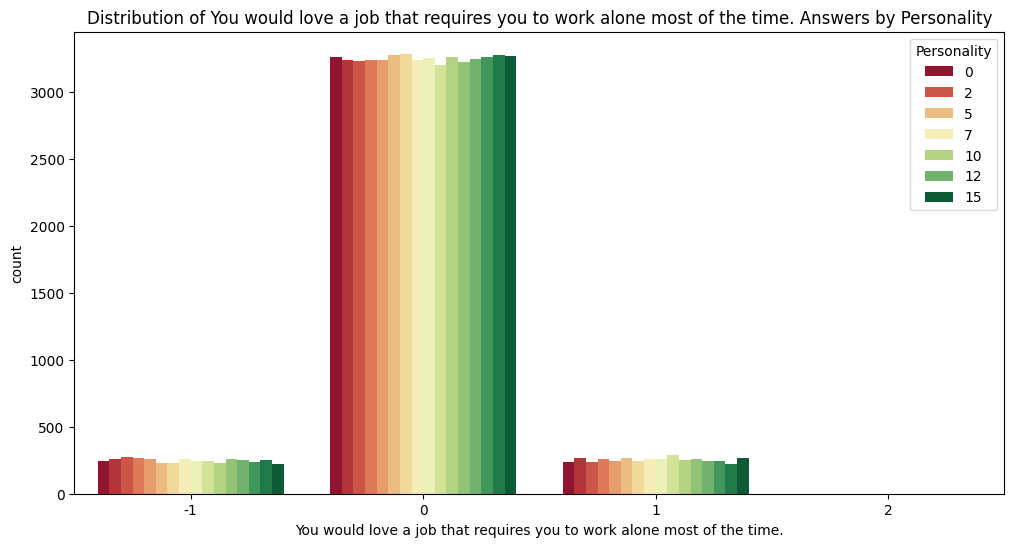

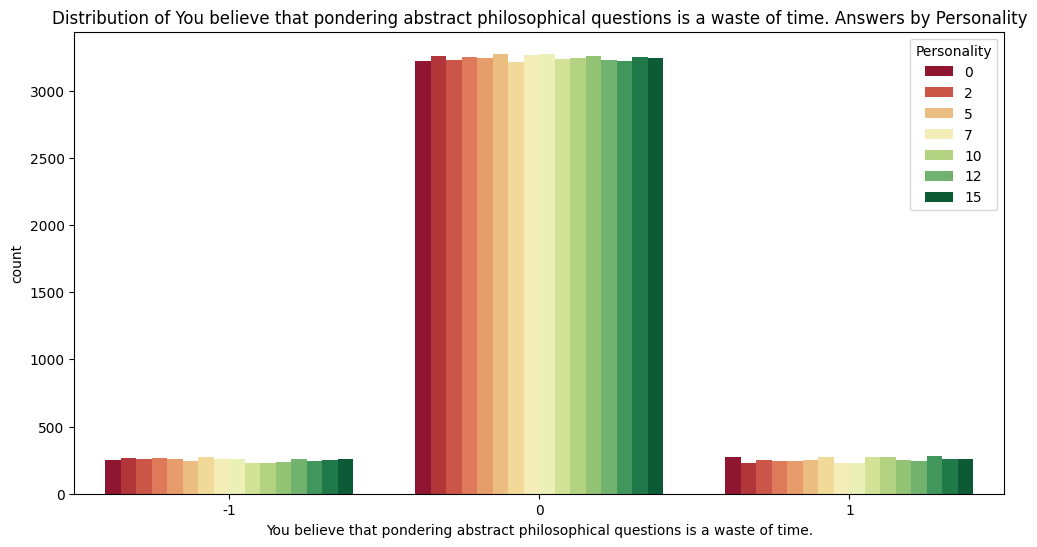

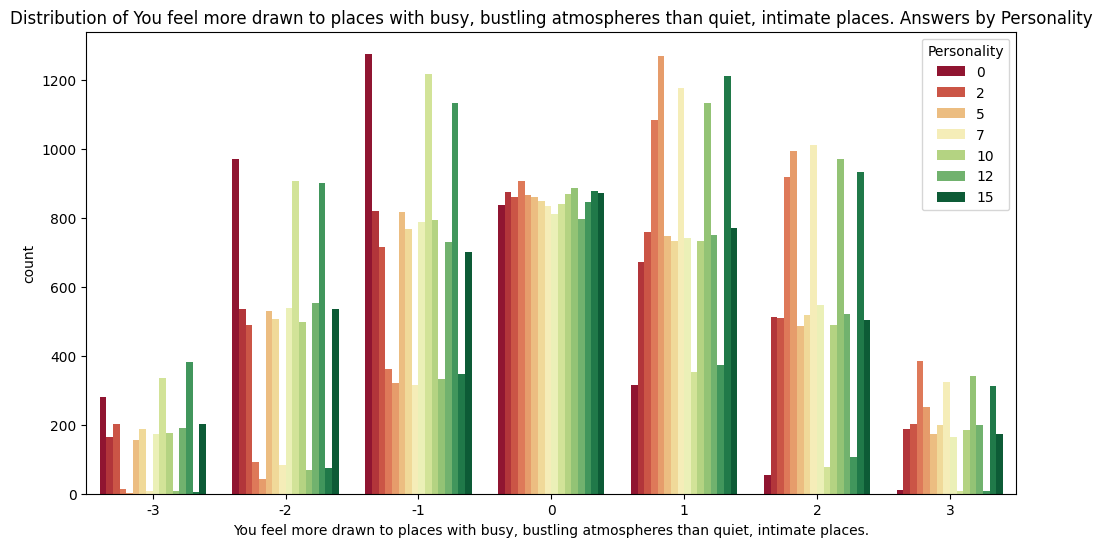

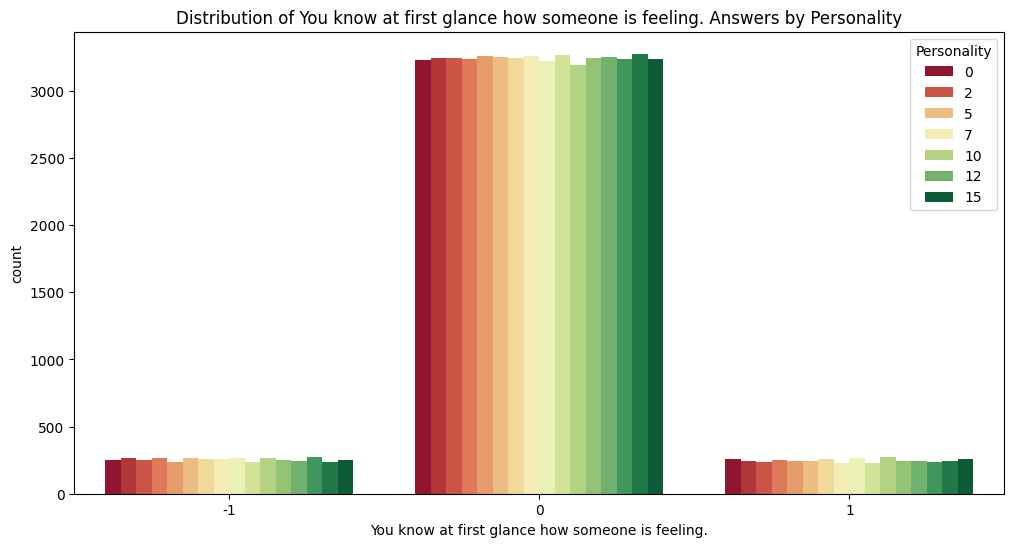

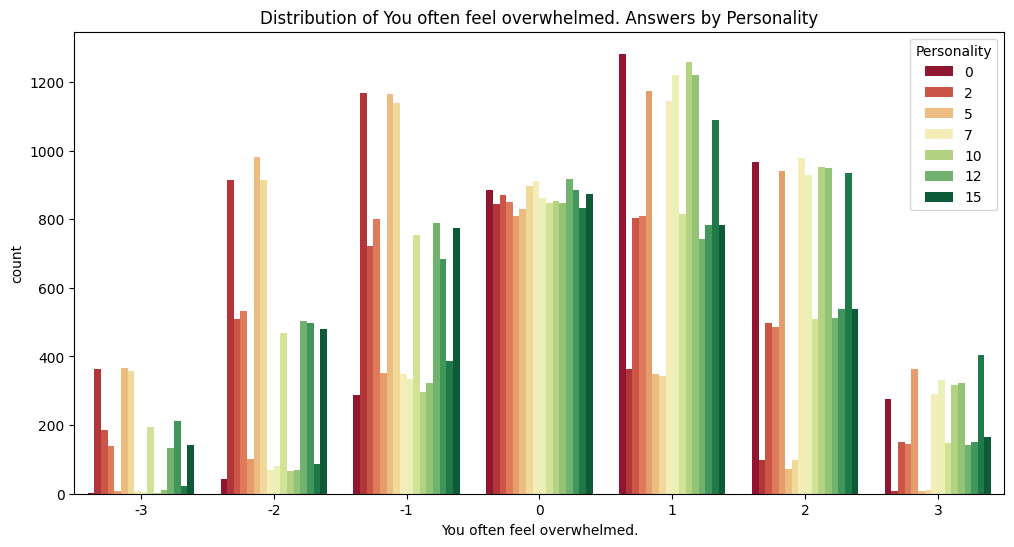

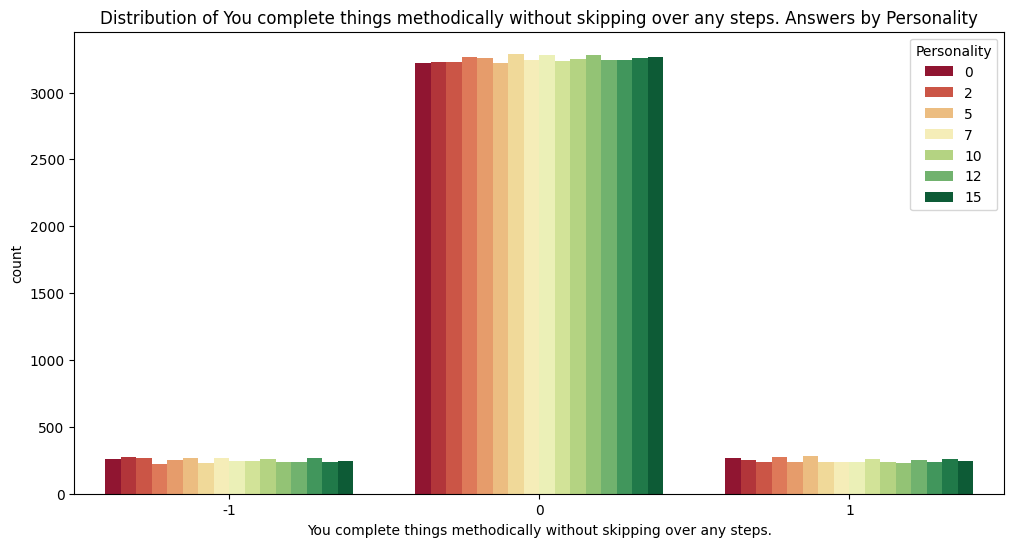

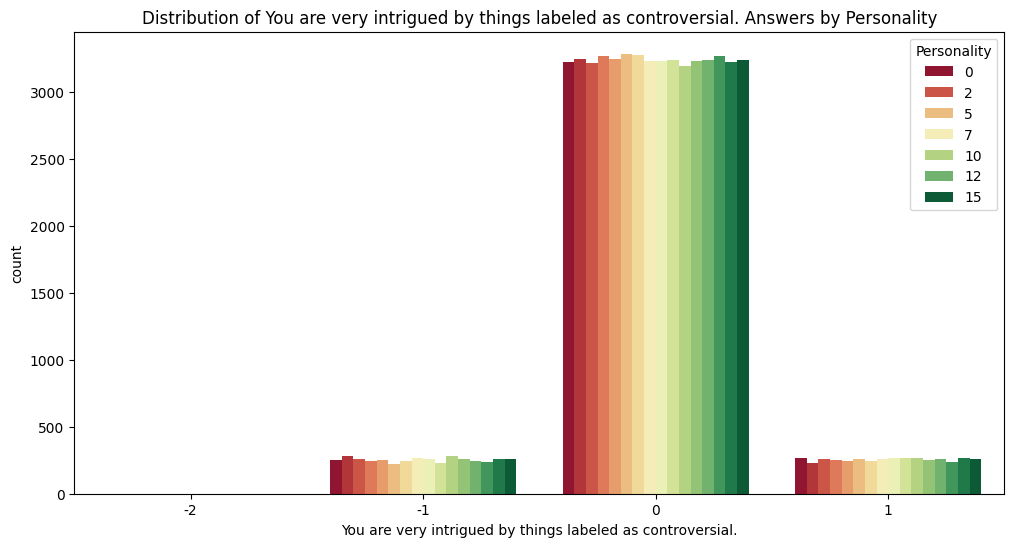

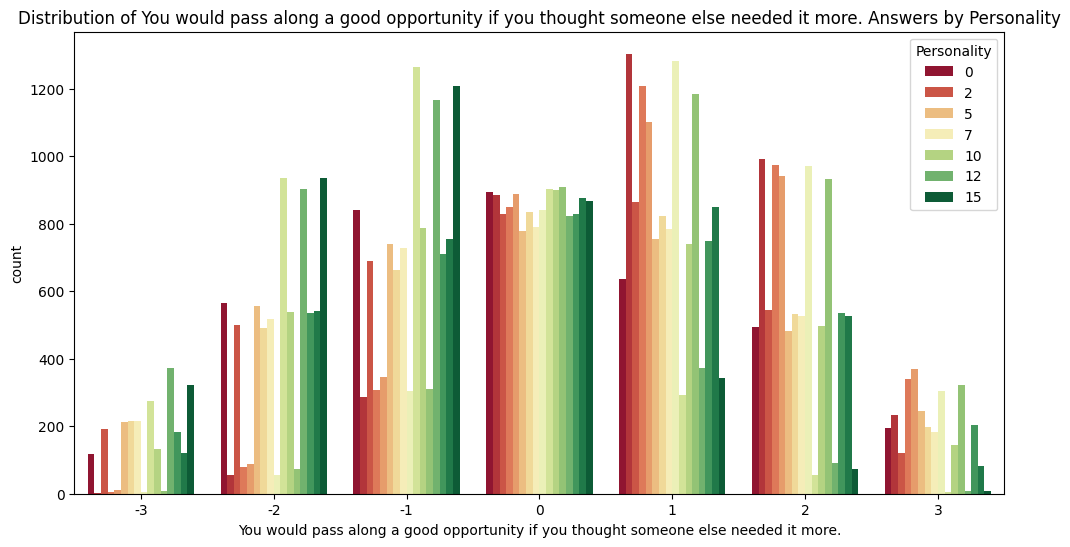

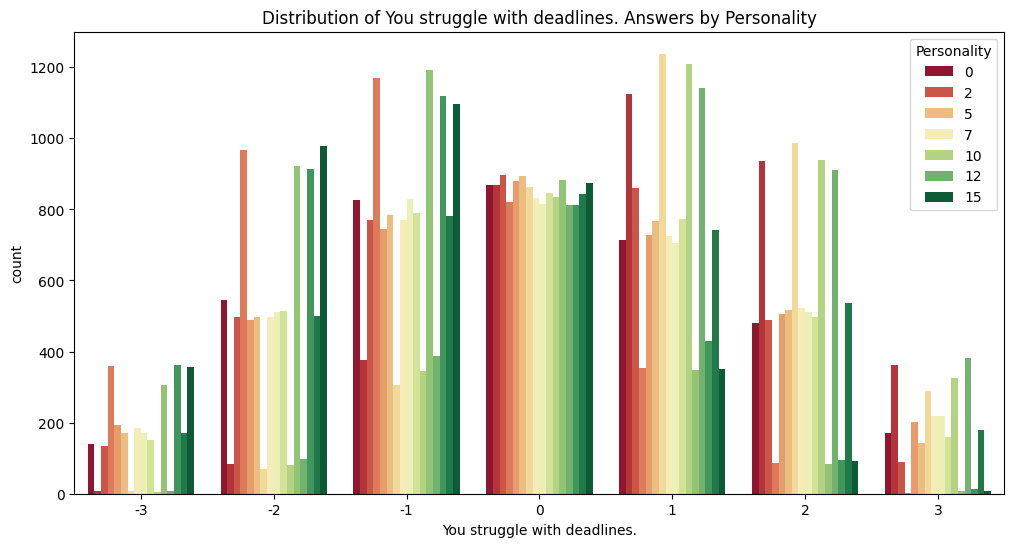

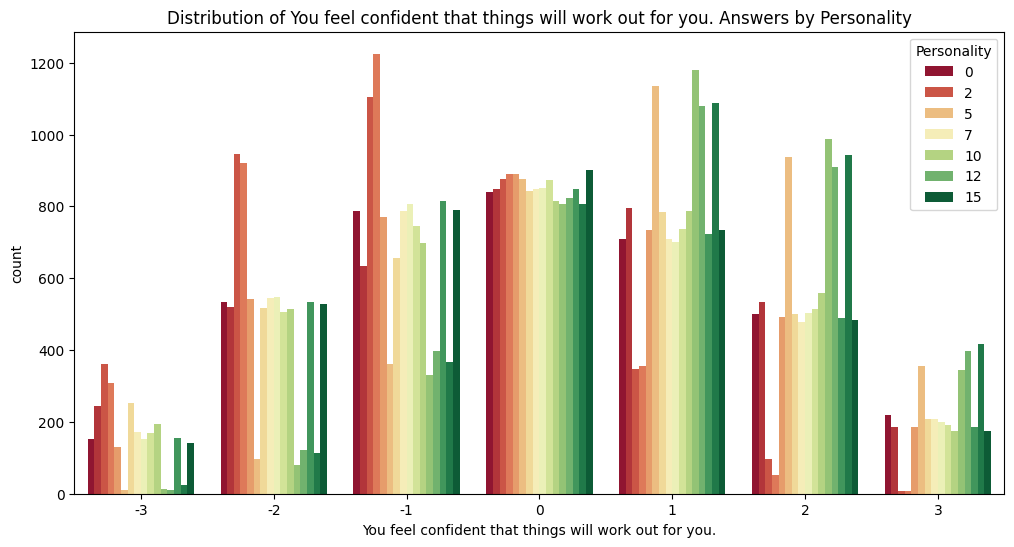

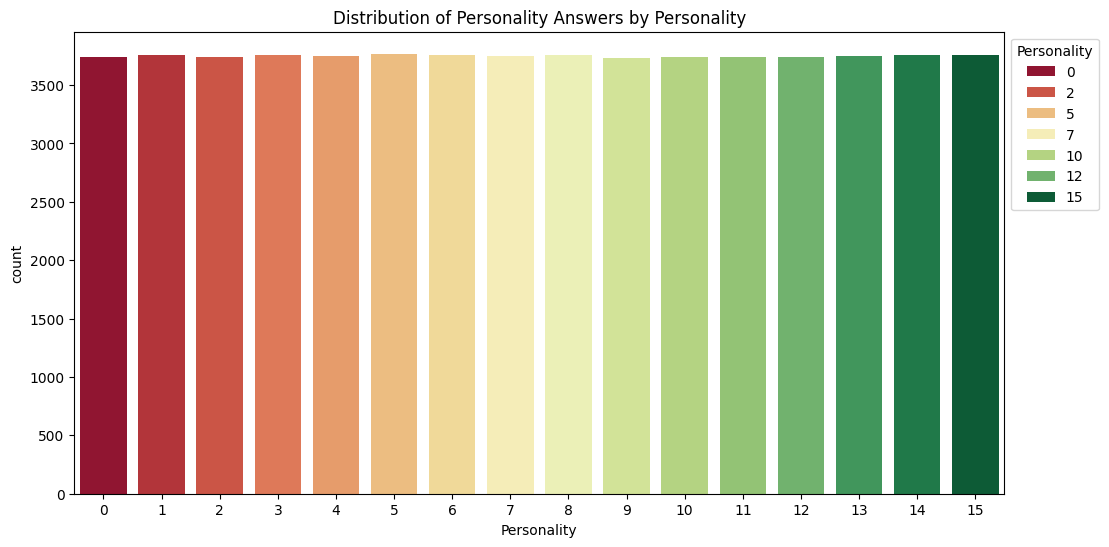

In [ ]:
for col in df.columns[1:]:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=col, hue="Personality", data=df, palette="RdYlGn")
    plt.title(f"Distribution of {col} by Personality")
    plt.legend(title="Personality", bbox_to_anchor=(1, 1))
    plt.show()